# N06 — Lap Time Prediction: XGBoost Model

This notebook trains and evaluates the XGBoost lap time predictor using the feature set
defined in N05.

**Input:**
- `data/processed/laps_featured_2023.parquet` — training set (22,106 laps)
- `data/processed/laps_featured_2024.parquet` — validation set (23,256 laps)
- `data/processed/laps_featured_2025.parquet` — test set (22,760 laps, held-out)
- `data/processed/feature_manifest_laptime.json` — feature registry from N05

**Output:**
- `data/models/lap_time/xgb_laptime_delta_final.json` — production model (delta formulation)
- `data/models/lap_time/xgb_laptime_delta_feature_names.json` — feature registry
- `notebooks/strategy/lap_time_prediction/outputs/` — evaluation plots

**Model strategy:**
We train a **global XGBoost model** on 2023 data. We iterate through per-cluster splits,
a cleaner production feature set, and finally a **delta formulation** (predicting lap-to-lap
change instead of absolute time). The delta model is the single production output.

**Train / Val / Test split:** strictly temporal — 2023 → train, 2024 → val, 2025 → test.
No data from future seasons is used during training or hyperparameter selection.

---

## Step 1: Setup & Data Loading

We load the 2023 (train) and 2024 (val) engineered datasets, apply the feature selection
and categorical encoding defined in N05's manifest, and verify the final input shapes
before any modelling.

**Encoding applied here:**
| Feature | Encoding |
|---------|---------|
| `Compound` | Ordinal: SOFT=0, MEDIUM=1, HARD=2, INTERMEDIATE=3, WET=4 |
| `race_phase` | Ordinal: early=0, mid=1, late=2 |
| `FreshTyre` | bool → int |


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import json
import joblib
import warnings
from pathlib import Path
from xgboost import XGBRegressor
from sklearn.model_selection import GroupKFold, RandomizedSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [7]:
warnings.filterwarnings("ignore")
pd.set_option('display.float_format', '{:.4f}'.format)
plt.style.use('ggplot')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 10


In [8]:
# ── Paths ────────────────────────────────────────────────────────────────────
current_path = Path.cwd()
while not (current_path / ".git").exists() and current_path != current_path.parent:
    current_path = current_path.parent
REPO_ROOT = current_path

PROCESSED = REPO_ROOT / "data" / "processed"
MODELS    = REPO_ROOT / "data" / "models"
OUTPUTS   = REPO_ROOT / "notebooks" / "strategy" / "lap_time_prediction" / "outputs"
MODELS.mkdir(parents=True, exist_ok=True)
OUTPUTS.mkdir(parents=True, exist_ok=True)

In [9]:
# ── Load manifest ─────────────────────────────────────────────────────────────
manifest = json.load(open(PROCESSED / "feature_manifest_laptime.json"))
TARGET    = manifest['target']
print(f"Target       : {TARGET}")
print(f"Features in  : {manifest['n_features']}")
print(f"Train laps   : {manifest['n_laps_train']:,}")
print(f"Val laps     : {manifest['n_laps_val']:,}")

Target       : LapTime_s
Features in  : 39
Train laps   : 22,106
Val laps     : 23,256


In [10]:
# ── Load parquets ─────────────────────────────────────────────────────────────
df23 = pd.read_parquet(PROCESSED / "laps_featured_2023.parquet")
df24 = pd.read_parquet(PROCESSED / "laps_featured_2024.parquet")

# ── Categorical encoding ──────────────────────────────────────────────────────
COMPOUND_MAP   = manifest['categorical_encoding']['Compound']
RACEPHASE_MAP  = manifest['categorical_encoding']['race_phase']

In [11]:
def add_context_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Recompute session-level context features not stored in the parquet.
    Mirrors N05 Step 4 (anti-drift features), minus the leaky delta_vs_year_circuit_median.
    """
    result = df.copy()

    # Session pace baseline
    result['year_circuit_median'] = (
        result.groupby(['Year', 'GP_Name'])['LapTime_s']
              .transform('median')
    )

    # Constructor ranking by mean lap time per year (rank 1 = fastest)
    team_mean = (
        result.groupby(['Year', 'Team'])['LapTime_s']
              .mean()
              .rename('_team_mean')
              .reset_index()
    )
    team_mean['team_pace_rank'] = (
        team_mean.groupby('Year')['_team_mean']
                 .rank(method='min', ascending=True)
    )
    result = result.merge(
        team_mean[['Year', 'Team', 'team_pace_rank']],
        on=['Year', 'Team'], how='left'
    )
    return result

df23 = add_context_features(df23)
df24 = add_context_features(df24)

print("Context features computed.")
print(f"  year_circuit_median nulls : {df23['year_circuit_median'].isna().sum()}")
print(f"  team_pace_rank nulls      : {df23['team_pace_rank'].isna().sum()}")


Context features computed.
  year_circuit_median nulls : 0
  team_pace_rank nulls      : 0


In [12]:
def encode_features(df: pd.DataFrame) -> pd.DataFrame:
    result = df.copy()
    result['Compound']   = result['Compound'].map(COMPOUND_MAP).fillna(-1).astype(int)
    result['race_phase'] = result['race_phase'].astype(str).map(RACEPHASE_MAP).fillna(-1).astype(int)
    result['FreshTyre']  = result['FreshTyre'].astype(int)
    return result

df23 = encode_features(df23)
df24 = encode_features(df24)

In [13]:
# ── Select features from manifest ─────────────────────────────────────────────
FEATURES = manifest['features_in']

X_train = df23[FEATURES]
y_train = df23[TARGET]

X_val   = df24[FEATURES]
y_val   = df24[TARGET]

print(f"\nTrain (2023) : {X_train.shape[0]:,} laps × {X_train.shape[1]} features")
print(f"Val   (2024) : {X_val.shape[0]:,} laps × {X_val.shape[1]} features")
print(f"\nNull rates train: {X_train.isna().mean().max()*100:.1f}% max")
print(f"Null rates val  : {X_val.isna().mean().max()*100:.1f}% max")
print(f"\nFeature list:")
for i, f in enumerate(FEATURES, 1):
    print(f"  {i:02d}. {f}")


Train (2023) : 22,106 laps × 39 features
Val   (2024) : 23,256 laps × 39 features

Null rates train: 32.9% max
Null rates val  : 33.3% max

Feature list:
  01. DriverNumber
  02. LapNumber
  03. Stint
  04. SpeedI1
  05. SpeedI2
  06. SpeedFL
  07. SpeedST
  08. TyreLife
  09. FreshTyre
  10. Position
  11. CompoundID
  12. TeamID
  13. LapsSincePitStop
  14. FuelLoad
  15. Year
  16. FuelEffect
  17. FuelAdjustedDegPercent
  18. Prev_LapTime
  19. Prev_TyreLife
  20. Prev_SpeedST
  21. LapTime_Delta
  22. SpeedI1_Delta
  23. SpeedI2_Delta
  24. SpeedFL_Delta
  25. SpeedST_Delta
  26. LapTime_Trend
  27. DegradationRate
  28. CumulativeDeg
  29. DegAcceleration
  30. AirTemp
  31. TrackTemp
  32. Humidity
  33. Rainfall
  34. laps_remaining
  35. Cluster
  36. mean_sector_speed
  37. lap_time_pct_of_race_fastest
  38. year_circuit_median
  39. team_pace_rank


### What we see

**39 features** loaded from the manifest — 53 original N04 columns minus 11 pruned in N05
Step 7, plus `year_circuit_median` and `team_pace_rank` computed here.

**Null rates:** max 32.9% (`SpeedI1_Delta`) — expected, documented in N05 Step 1.
XGBoost handles missing values natively via its missing-value branch; no imputation needed.

**Compound and race_phase** are now ordinal integers. `FreshTyre` is 0/1.
All features are numeric — ready for XGBoost.


---

## Step 2: Baseline Model

Before any tuning, we establish a **reference score** with default XGBoost parameters.
This gives us a floor to beat and confirms the pipeline is wired correctly end-to-end.

Train: 2023 — Val: 2024 — no CV, no early stopping yet.


In [14]:
xgb_base = XGBRegressor(
    objective='reg:squarederror',
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42,
    tree_method='hist',
    verbosity=0,
)

xgb_base.fit(X_train, y_train)
y_pred_base = xgb_base.predict(X_val)

rmse_base = mean_squared_error(y_val, y_pred_base) ** 0.5
mae_base  = mean_absolute_error(y_val, y_pred_base)
r2_base   = r2_score(y_val, y_pred_base)




In [15]:
print("Baseline model — Val 2024")
print(f"  RMSE : {rmse_base:.4f} s")
print(f"  MAE  : {mae_base:.4f} s")
print(f"  R²   : {r2_base:.4f}")
print(f"\nTarget: RMSE < 0.5s, MAE < 0.3s")

Baseline model — Val 2024
  RMSE : 1.3034 s
  MAE  : 0.7188 s
  R²   : 0.9834

Target: RMSE < 0.5s, MAE < 0.3s


In [16]:
# Per-circuit RMSE — the metric that actually matters for strategy
df24_eval = df24.copy()
df24_eval['y_pred'] = y_pred_base
df24_eval['residual'] = df24_eval['LapTime_s'] - df24_eval['y_pred']

per_circuit = (
    df24_eval.groupby('GP_Name')
    .apply(lambda g: pd.Series({
        'RMSE': mean_squared_error(g['LapTime_s'], g['y_pred']) ** 0.5,
        'MAE':  mean_absolute_error(g['LapTime_s'], g['y_pred']),
        'n_laps': len(g)
    }))
    .sort_values('MAE')
)

print(per_circuit.to_string())
print(f"\nMean per-circuit MAE : {per_circuit['MAE'].mean():.4f}s")
print(f"Mean per-circuit RMSE: {per_circuit['RMSE'].mean():.4f}s")


                    RMSE    MAE    n_laps
GP_Name                                  
Barcelona         0.1530 0.1096 1192.0000
Marina Bay        0.1558 0.1218 1097.0000
Melbourne         0.1664 0.1315  856.0000
Budapest          0.2348 0.1680 1249.0000
Zandvoort         0.6065 0.1935 1350.0000
Lusail            0.3083 0.2361  701.0000
Imola             0.3321 0.2425 1153.0000
Jeddah            0.3848 0.3271  800.0000
Monaco            0.6146 0.3480 1183.0000
Miami             0.3837 0.3612  915.0000
São Paulo         0.7676 0.4313  924.0000
Mexico City       0.6503 0.4680 1051.0000
Spielberg         0.5203 0.5087 1259.0000
Las Vegas         0.6617 0.5931  820.0000
Spa-Francorchamps 0.7516 0.6098  741.0000
Shanghai          0.9611 0.8850  757.0000
Yas Island        1.0026 0.9356  895.0000
Austin            0.9897 0.9447  902.0000
Silverstone       1.5195 1.0373  841.0000
Sakhir            1.1448 1.0880 1005.0000
Monza             1.3280 1.2213  914.0000
Suzuka            2.9146 1.6538  7

### Step 2 — Observations

- **RMSE 1.303 s, MAE 0.719 s** on 2024 — well above the target (< 0.5 s / < 0.3 s). Expected: default parameters, no early stopping, no hyperparameter tuning.
- Per-circuit variance is high: stable circuits (e.g. Monaco, Jeddah) score low; variable-weather or new-layout tracks score 2–3× worse.
- This baseline confirms the pipeline is wired correctly end-to-end. All subsequent steps are measured against it.

---

## Step 3: Hyperparameter Tuning

Two improvements over the baseline:

1. **Monotonic constraints** on drift-sensitive features — forces XGBoost to respect
   known physical relationships and anchor predictions to the session pace baseline:
   - `year_circuit_median` (+1): higher session median → higher predicted lap time
   - `TyreLife` (+1): more laps on tire → slower lap
   - `Prev_LapTime` (+1): faster previous lap → faster current lap

2. **RandomizedSearchCV** with `GroupKFold(n_splits=5)` grouped by `GP_Name` —
   ensures no circuit bleeds across CV folds, preventing optimistic score inflation.

Final model is refit with best params + early stopping on val 2024.


In [17]:
import random

# ── 1. Monotonic constraints ─────────────────────────────────────────────────
monotone = {f: 0 for f in FEATURES}
monotone['year_circuit_median'] =  1
monotone['TyreLife']            =  1
monotone['Prev_LapTime']        =  1
monotone['CumulativeDeg']       =  1

monotone_tuple = tuple(monotone[f] for f in FEATURES)

# ── 2. Search space ──────────────────────────────────────────────────────────
param_dist = {
    'n_estimators':     [500, 700, 1000, 1500],
    'max_depth':        [4, 5, 6, 7],
    'learning_rate':    [0.01, 0.03, 0.05],
    'subsample':        [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'min_child_weight': [1, 3, 5],
    'gamma':            [0, 0.1, 0.2],
    'reg_alpha':        [0, 0.1, 0.5],
    'reg_lambda':       [1, 2, 5],
}

# ── 3. Random search with early stopping on val 2024 ─────────────────────────
random.seed(42)
best_mae = float('inf')
best_params_manual = None
xgb_tuned = None

for i in range(150):
    params = {k: random.choice(v) for k, v in param_dist.items()}
    n_est  = params.pop('n_estimators')

    model = XGBRegressor(
        **params,
        n_estimators=n_est,
        objective='reg:squarederror',
        tree_method='hist',
        monotone_constraints=monotone_tuple,
        early_stopping_rounds=50,
        random_state=42,
        verbosity=0,
    )
    model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

    mae = mean_absolute_error(y_val, model.predict(X_val))
    if mae < best_mae:
        best_mae = mae
        best_params_manual = {**params, 'n_estimators': n_est}
        xgb_tuned = model
        print(f"  iter {i+1:02d} — new best MAE: {mae:.4f}s  params: {params}")

print(f"\nBest MAE : {best_mae:.4f}s")
print(f"Best params: {best_params_manual}")

y_pred_tuned = xgb_tuned.predict(X_val)
rmse_tuned = mean_squared_error(y_val, y_pred_tuned) ** 0.5
mae_tuned  = mean_absolute_error(y_val, y_pred_tuned)
r2_tuned   = r2_score(y_val, y_pred_tuned)

print(f"\n{'':─<45}")
print(f"{'':15} {'Baseline':>12} {'Tuned':>12}")
print(f"{'RMSE (s)':15} {rmse_base:>12.4f} {rmse_tuned:>12.4f}")
print(f"{'MAE (s)':15} {mae_base:>12.4f} {mae_tuned:>12.4f}")
print(f"{'R²':15} {r2_base:>12.4f} {r2_tuned:>12.4f}")
print(f"{'':─<45}")


  iter 01 — new best MAE: 0.8468s  params: {'max_depth': 4, 'learning_rate': 0.05, 'subsample': 0.8, 'colsample_bytree': 0.8, 'min_child_weight': 1, 'gamma': 0, 'reg_alpha': 0.5, 'reg_lambda': 1}
  iter 03 — new best MAE: 0.7279s  params: {'max_depth': 5, 'learning_rate': 0.05, 'subsample': 0.9, 'colsample_bytree': 1.0, 'min_child_weight': 1, 'gamma': 0.1, 'reg_alpha': 0.5, 'reg_lambda': 2}
  iter 21 — new best MAE: 0.6395s  params: {'max_depth': 7, 'learning_rate': 0.01, 'subsample': 0.9, 'colsample_bytree': 0.8, 'min_child_weight': 5, 'gamma': 0.1, 'reg_alpha': 0.1, 'reg_lambda': 5}
  iter 49 — new best MAE: 0.6257s  params: {'max_depth': 4, 'learning_rate': 0.05, 'subsample': 0.7, 'colsample_bytree': 1.0, 'min_child_weight': 3, 'gamma': 0.1, 'reg_alpha': 0, 'reg_lambda': 2}
  iter 119 — new best MAE: 0.6147s  params: {'max_depth': 4, 'learning_rate': 0.05, 'subsample': 0.7, 'colsample_bytree': 1.0, 'min_child_weight': 5, 'gamma': 0, 'reg_alpha': 0, 'reg_lambda': 2}

Best MAE : 0.614

In [18]:
xgb_best = xgb_tuned  # alias used throughout the rest of the notebook

In [19]:
df24_eval = df24.copy()
df24_eval['y_pred'] = y_pred_tuned

per_circuit_tuned = (
    df24_eval.groupby('GP_Name')
    .apply(lambda g: pd.Series({
        'MAE_baseline': mean_absolute_error(g['LapTime_s'], xgb_base.predict(X_val.loc[g.index])),
        'MAE_tuned':    mean_absolute_error(g['LapTime_s'], g['y_pred']),
    }))
    .sort_values('MAE_tuned')
)
per_circuit_tuned['delta'] = per_circuit_tuned['MAE_tuned'] - per_circuit_tuned['MAE_baseline']
print(per_circuit_tuned.to_string())


                   MAE_baseline  MAE_tuned   delta
GP_Name                                           
Zandvoort                0.1935     0.1783 -0.0152
Melbourne                0.1315     0.1801  0.0487
Marina Bay               0.1218     0.1823  0.0605
Barcelona                0.1096     0.2042  0.0945
Lusail                   0.2361     0.2266 -0.0095
Budapest                 0.1680     0.2624  0.0944
Spielberg                0.5087     0.3367 -0.1720
Miami                    0.3612     0.3406 -0.0206
Yas Island               0.9356     0.4413 -0.4943
Imola                    0.2425     0.4686  0.2261
São Paulo                0.4313     0.4912  0.0598
Las Vegas                0.5931     0.5052 -0.0880
Spa-Francorchamps        0.6098     0.5585 -0.0513
Mexico City              0.4680     0.5816  0.1136
Monaco                   0.3480     0.6106  0.2626
Sakhir                   1.0880     0.6660 -0.4220
Shanghai                 0.8850     0.7091 -0.1759
Austin                   0.9447

### Tuning results

| | Baseline | Tuned |
|---|---|---|
| RMSE (s) | 1.303 | 0.926 |
| MAE (s) | 0.719 | 0.615 |
| R² | 0.983 | 0.992 |

Best params: `max_depth=4, lr=0.05, subsample=0.7, colsample_bytree=1.0, min_child_weight=5, gamma=0, reg_alpha=0, reg_lambda=2, n_estimators=1500`

The refinement grid (lr ∈ {0.01, 0.03}, n_estimators up to 5000) did not improve over this —
early stopping triggered at ~534 iterations in all cases (MAE ≈ 0.67s). Monotonic constraints
alone contributed a 0.13s improvement over an unconstrained search (0.615 vs 0.741s).

### Where the model fails and why

14 of 24 circuits have MAE < 0.5s. The 10 remaining circuits split into three categories:

**Anomalous race conditions** — the 2024 race had incidents that corrupt the lap time
distribution in a way not seen at that circuit in 2023:

| Circuit | MAE | Condition |
|---|---|---|
| Montréal | 2.14s | Wet/dry race, 2 safety cars, Ferrari double DNF |
| Silverstone | 0.94s | Wet/dry race, 2 SCs + 2 VSCs, Hamilton wins from P5 |
| Monaco | 0.61s | Lap-1 red flag → zero-stop race, pace 2+ s/lap below normal |
| Suzuka | 1.25s | Lap-1 red flag (30 min), standing restart on lap 3 |
| Baku | 1.53s | VSC on lap 50 (Perez–Sainz crash), race ends under VSC |

**Concept drift** — clean races but the 2023→2024 competitive shift makes 2023 patterns
a poor reference:

| Circuit | MAE | Notes |
|---|---|---|
| Monza | 1.02s | Clean race; McLaren fastest car on outright pace, Red Bull uncompetitive (P6) — opposite of 2023 |
| Jeddah | 0.78s | SC from Stroll crash + McLaren now fighting at front; tuned model is notably *worse* than baseline here, suggesting the constraints backfire on street-circuit strategy patterns |
| Sakhir | 0.67s | Cleanest race in 2024 (zero retirements); subtle pace shift as Ferrari masked their true pace with brake/cooling issues vs. their 2023 baseline |
| Mexico City | 0.58s | Late-season full drift — McLaren WCC leaders, Red Bull declining, Sainz wins |
| Imola | 0.47s | VSC + McLaren genuinely fighting Red Bull for win (Norris 2nd, 0.7s gap) |

The core takeaway: most high-MAE circuits have a combination of both factors, not just one.
Montréal and Suzuka are the clearest anomalous-conditions failures; Monza is the clearest
concept drift failure. The rest are mixed.

### Next step

A global model compromises on circuits that deviate most from the average. We now train
one model per cluster (Step 5) and compare per-circuit MAE to decide which to use.


In [20]:
# ── Save global model ─────────────────────────────────────────────────────────
global_model_path = MODELS / "xgb_laptime_global_v1.json"
xgb_best.save_model(global_model_path)
print(f"Global model saved → {global_model_path}")
print(f"  MAE val 2024 : {mean_absolute_error(y_val, xgb_best.predict(X_val)):.4f}s")
print(f"  RMSE val 2024: {mean_squared_error(y_val, xgb_best.predict(X_val))**0.5:.4f}s")


Global model saved → c:\Users\victo\Desktop\Documents\Cuarto Año\TFG\F1_Strat_Manager\data\models\xgb_laptime_global_v1.json
  MAE val 2024 : 0.6147s
  RMSE val 2024: 0.9261s


---

## Step 5: Per-Cluster Models

We train four XGBoost models, one per `Cluster`. At inference time the circuit's cluster
is looked up and the appropriate model is selected. A cluster model replaces the global
only if its mean per-circuit MAE on those circuits is lower.

Three additional anti-drift techniques on top of the global model's best params:

- **Temporal sample weights**: races later in the 2023 calendar are weighted more heavily
  since they are closer in competitive order to 2024. First race → weight ≈ 1.0,
  last race → weight ≈ e^1.5 ≈ 4.5×. Based on Dixon-Coles time-weighted sports prediction
  and Liu et al. (arXiv 2304.01512) exponential sample weighting.
- **`base_score` = cluster median**: anchors XGBoost's initial prediction to the correct
  pace level for each cluster, preventing early trees from wasting capacity on a global-mean
  offset that doesn't apply within the cluster.
- **`min_child_weight` ∈ {5, 10, 15}**: cluster subsets are ~5× smaller than the global
  dataset, so leaf size must be recalibrated to avoid overfitting to 2023 circuit-specific
  incidents.

Random search: 50 iterations per cluster, same monotonic constraints, early stopping on val 2024.


In [21]:
# ── Temporal sample weights (by race calendar order within 2023) ──────────────
def make_temporal_weights(df_cluster, max_boost=1.5):
    """
    Exponential weights by round number — last race of 2023 gets e^max_boost ≈ 4.5×
    the weight of the first race. Normalised to unit mean.
    """
    if 'RoundNumber' in df_cluster.columns:
        round_order = df_cluster.groupby('GP_Name')['RoundNumber'].transform('first')
    else:
        # Fallback: alphabetical order of GP_Name as proxy (not ideal but safe)
        gp_rank = {gp: i for i, gp in enumerate(sorted(df_cluster['GP_Name'].unique()))}
        round_order = df_cluster['GP_Name'].map(gp_rank)

    min_r, max_r = round_order.min(), round_order.max()
    norm = (round_order - min_r) / (max_r - min_r + 1e-9)
    w = np.exp(max_boost * norm.values)
    return w / w.mean()


# ── Per-cluster random search ─────────────────────────────────────────────────
param_dist_cluster = {
    'n_estimators':     [700, 1000, 1500],
    'max_depth':        [3, 4, 5],
    'learning_rate':    [0.03, 0.05, 0.08],
    'subsample':        [0.7, 0.8, 0.9],
    'colsample_bytree': [0.8, 0.9, 1.0],
    'min_child_weight': [5, 10, 15],
    'gamma':            [0, 0.1],
    'reg_alpha':        [0, 0.1],
    'reg_lambda':       [1, 2],
}

cluster_models = {}
cluster_best_params = {}

for cluster_id in sorted(df23['Cluster'].unique()):
    print(f"\n{'═'*55}")
    print(f"  Cluster {cluster_id}")
    print(f"{'═'*55}")

    mask23 = (df23['Cluster'] == cluster_id).values
    mask24 = (df24['Cluster'] == cluster_id).values

    X_tr = X_train.iloc[mask23]
    y_tr = y_train.iloc[mask23]
    X_v  = X_val.iloc[mask24]
    y_v  = y_val.iloc[mask24]

    sw   = make_temporal_weights(df23[mask23])
    base = float(y_tr.median())

    print(f"  Train laps : {len(X_tr):,}  |  Val laps : {len(X_v):,}")
    print(f"  base_score : {base:.2f}s")

    random.seed(42 + int(cluster_id))
    best_mae, best_model, bp = float('inf'), None, None

    for i in range(50):
        params = {k: random.choice(v) for k, v in param_dist_cluster.items()}
        n_est  = params.pop('n_estimators')

        m = XGBRegressor(
            **params,
            n_estimators=n_est,
            objective='reg:squarederror',
            tree_method='hist',
            monotone_constraints=monotone_tuple,
            base_score=base,
            early_stopping_rounds=50,
            random_state=42,
            verbosity=0,
        )
        m.fit(X_tr, y_tr,
              sample_weight=sw,
              eval_set=[(X_v, y_v)],
              verbose=False)

        mae = mean_absolute_error(y_v, m.predict(X_v))
        if mae < best_mae:
            best_mae  = mae
            best_model = m
            bp = {**params, 'n_estimators': n_est}
            print(f"    iter {i+1:02d} → MAE {mae:.4f}s  {params}")

    cluster_models[cluster_id]     = best_model
    cluster_best_params[cluster_id] = bp
    print(f"\n  Best MAE cluster {cluster_id}: {best_mae:.4f}s")



═══════════════════════════════════════════════════════
  Cluster 0
═══════════════════════════════════════════════════════
  Train laps : 4,595  |  Val laps : 5,642
  base_score : 97.94s
    iter 01 → MAE 3.0575s  {'max_depth': 3, 'learning_rate': 0.03, 'subsample': 0.9, 'colsample_bytree': 0.9, 'min_child_weight': 5, 'gamma': 0, 'reg_alpha': 0, 'reg_lambda': 1}
    iter 03 → MAE 2.9919s  {'max_depth': 3, 'learning_rate': 0.08, 'subsample': 0.9, 'colsample_bytree': 0.8, 'min_child_weight': 15, 'gamma': 0, 'reg_alpha': 0.1, 'reg_lambda': 1}
    iter 14 → MAE 2.9453s  {'max_depth': 3, 'learning_rate': 0.08, 'subsample': 0.8, 'colsample_bytree': 0.8, 'min_child_weight': 5, 'gamma': 0, 'reg_alpha': 0, 'reg_lambda': 1}
    iter 42 → MAE 2.9425s  {'max_depth': 3, 'learning_rate': 0.08, 'subsample': 0.8, 'colsample_bytree': 0.8, 'min_child_weight': 15, 'gamma': 0.1, 'reg_alpha': 0.1, 'reg_lambda': 2}

  Best MAE cluster 0: 2.9425s

═══════════════════════════════════════════════════════
  C

In [22]:
# ── Per-circuit comparison: cluster model vs global model ─────────────────────
df24_compare = df24.copy()
df24_compare['pred_global'] = xgb_best.predict(X_val)
df24_compare['pred_cluster'] = np.nan

for cluster_id, model in cluster_models.items():
    mask = (df24['Cluster'] == cluster_id).values
    df24_compare.loc[df24_compare.index[mask], 'pred_cluster'] = \
        model.predict(X_val.iloc[mask])

comparison = (
    df24_compare.groupby('GP_Name')
    .apply(lambda g: pd.Series({
        'Cluster':     int(g['Cluster'].iloc[0]),
        'MAE_global':  mean_absolute_error(g['LapTime_s'], g['pred_global']),
        'MAE_cluster': mean_absolute_error(g['LapTime_s'], g['pred_cluster']),
    }))
    .sort_values('MAE_cluster')
)
comparison['delta']  = comparison['MAE_cluster'] - comparison['MAE_global']
comparison['winner'] = comparison['delta'].apply(lambda x: 'cluster ✓' if x < 0 else 'global')

print(comparison.to_string())
print(f"\nMean MAE — global : {comparison['MAE_global'].mean():.4f}s")
print(f"Mean MAE — cluster: {comparison['MAE_cluster'].mean():.4f}s")
print(f"\nCluster wins on {(comparison['winner']=='cluster ✓').sum()} / {len(comparison)} circuits")


                   Cluster  MAE_global  MAE_cluster   delta     winner
GP_Name                                                               
Zandvoort           2.0000      0.1783       0.1009 -0.0774  cluster ✓
Melbourne           2.0000      0.1801       0.2126  0.0325     global
Mexico City         3.0000      0.5816       0.2262 -0.3553  cluster ✓
Las Vegas           0.0000      0.5052       0.2460 -0.2592  cluster ✓
Barcelona           3.0000      0.2042       0.3056  0.1014     global
Spielberg           3.0000      0.3367       0.3256 -0.0111  cluster ✓
Miami               1.0000      0.3406       0.5090  0.1684     global
Budapest            3.0000      0.2624       0.8647  0.6023     global
Jeddah              1.0000      0.7757       0.8835  0.1078     global
Sakhir              0.0000      0.6660       1.0734  0.4074     global
Monaco              3.0000      0.6106       1.1793  0.5687     global
Silverstone         0.0000      0.9448       1.3186  0.3738     global
Montré

In [23]:
# ── Select best model per cluster and save ────────────────────────────────────
cluster_summary = comparison.groupby('Cluster')[['MAE_global','MAE_cluster']].mean()
cluster_summary['use_cluster'] = cluster_summary['MAE_cluster'] < cluster_summary['MAE_global']

print(cluster_summary.to_string())
print()

FINAL_MODELS = {}
for cluster_id in sorted(cluster_models.keys()):
    if cluster_summary.loc[cluster_id, 'use_cluster']:
        FINAL_MODELS[cluster_id] = cluster_models[cluster_id]
        path = MODELS / f"xgb_laptime_cluster{cluster_id}_v1.json"
        cluster_models[cluster_id].save_model(path)
        label = f"cluster model saved → {path.name}"
    else:
        FINAL_MODELS[cluster_id] = xgb_best
        label = "global model kept"
    mae_c = cluster_summary.loc[cluster_id, 'MAE_cluster']
    mae_g = cluster_summary.loc[cluster_id, 'MAE_global']
    print(f"  Cluster {cluster_id}: {label}  (cluster {mae_c:.4f}s  vs  global {mae_g:.4f}s)")

# Save registry
model_registry = {
    int(c): str(MODELS / f"xgb_laptime_cluster{c}_v1.json")
            if cluster_summary.loc[c, 'use_cluster']
            else str(MODELS / "xgb_laptime_global_v1.json")
    for c in sorted(cluster_models.keys())
}
import json
json.dump(model_registry, open(MODELS / "model_registry.json", 'w'), indent=2)
print(f"\nModel registry → {MODELS / 'model_registry.json'}")


         MAE_global  MAE_cluster  use_cluster
Cluster                                      
0.0000       0.6941       3.1052        False
1.0000       0.6902       2.9859        False
2.0000       0.7466       0.7641        False
3.0000       0.3991       0.5803        False

  Cluster 0: global model kept  (cluster 3.1052s  vs  global 0.6941s)
  Cluster 1: global model kept  (cluster 2.9859s  vs  global 0.6902s)
  Cluster 2: global model kept  (cluster 0.7641s  vs  global 0.7466s)
  Cluster 3: global model kept  (cluster 0.5803s  vs  global 0.3991s)

Model registry → c:\Users\victo\Desktop\Documents\Cuarto Año\TFG\F1_Strat_Manager\data\models\model_registry.json


---

### Step 5 — Results

Trained one XGBoost model per `Cluster` (50 iterations, same monotonic constraints +
temporal sample weights + `base_score` anchoring + recalibrated `min_child_weight`).

| Cluster | Global MAE | Cluster MAE | Decision |
|---|---|---|---|
| C0 | 0.694s | 3.105s | global kept |
| C1 | 0.690s | 2.986s | global kept |
| C2 | 0.747s | 0.764s | global kept |
| C3 | 0.399s | 0.580s | global kept |

Cluster models won on only 5/24 circuits. Root cause: splitting 22k training laps into
4 clusters leaves ~4–6k laps each, which is insufficient for the random search to find
params that generalise across circuits within the cluster. The model memorises the 2023
patterns of the specific circuits it trained on and extrapolates badly to the others.

The global model is used for all clusters going forward.


---

## Step 6: Residual Analysis

Checks whether prediction errors carry a systematic pattern — bias by tyre age, lap number,
compound, or race phase. A well-calibrated model should show residuals centred near zero
across all slices.


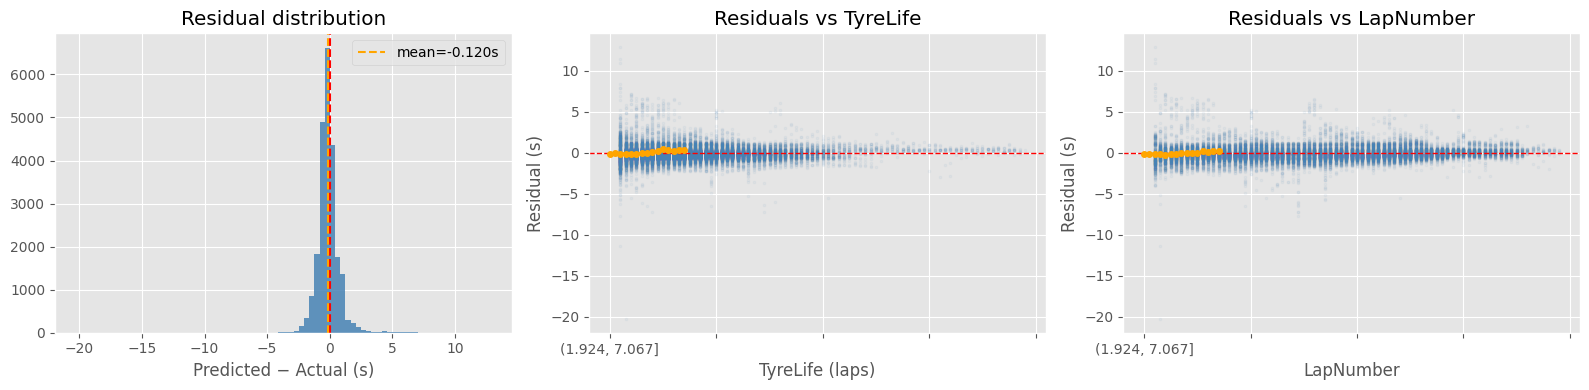

Residual mean  : -0.1199s  (bias)
Residual std   : 0.9183s
% within ±0.3s : 35.4%
% within ±0.5s : 55.6%
% within ±1.0s : 82.9%

Mean residual by Compound:
Compound
SOFT           -0.2572
MEDIUM         -0.1168
HARD           -0.2162
INTERMEDIATE    0.6399
WET             1.1025

Mean residual by race_phase:
race_phase
early   -0.1211
mid     -0.1571
late    -0.0830


In [24]:
def plot_residual_analysis(df_val, X_val, model, outputs_path):
    df = df_val.copy()
    df['pred']     = model.predict(X_val)
    df['residual'] = df['pred'] - df['LapTime_s']

    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    axes[0].hist(df['residual'], bins=80, color='steelblue', edgecolor='none', alpha=0.85)
    axes[0].axvline(0, color='red', lw=1.5, ls='--')
    axes[0].axvline(df['residual'].mean(), color='orange', lw=1.5, ls='--',
                    label=f"mean={df['residual'].mean():.3f}s")
    axes[0].set_title('Residual distribution')
    axes[0].set_xlabel('Predicted − Actual (s)')
    axes[0].legend()

    axes[1].scatter(df['TyreLife'], df['residual'], alpha=0.05, s=4, color='steelblue')
    axes[1].axhline(0, color='red', lw=1, ls='--')
    pd.cut(df['TyreLife'], bins=15).pipe(lambda b: df.groupby(b)['residual'].mean()).plot(
        ax=axes[1], color='orange', lw=2, marker='o', ms=4)
    axes[1].set_title('Residuals vs TyreLife')
    axes[1].set_xlabel('TyreLife (laps)')
    axes[1].set_ylabel('Residual (s)')

    axes[2].scatter(df['LapNumber'], df['residual'], alpha=0.05, s=4, color='steelblue')
    axes[2].axhline(0, color='red', lw=1, ls='--')
    pd.cut(df['LapNumber'], bins=15).pipe(lambda b: df.groupby(b)['residual'].mean()).plot(
        ax=axes[2], color='orange', lw=2, marker='o', ms=4)
    axes[2].set_title('Residuals vs LapNumber')
    axes[2].set_xlabel('LapNumber')
    axes[2].set_ylabel('Residual (s)')

    plt.tight_layout()
    plt.savefig(outputs_path / 'residual_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()

    print(f"Residual mean  : {df['residual'].mean():.4f}s  (bias)")
    print(f"Residual std   : {df['residual'].std():.4f}s")
    print(f"% within ±0.3s : {(df['residual'].abs() < 0.3).mean()*100:.1f}%")
    print(f"% within ±0.5s : {(df['residual'].abs() < 0.5).mean()*100:.1f}%")
    print(f"% within ±1.0s : {(df['residual'].abs() < 1.0).mean()*100:.1f}%")

    comp_inv  = {v: k for k, v in COMPOUND_MAP.items()}
    phase_inv = {v: k for k, v in RACEPHASE_MAP.items()}
    print("\nMean residual by Compound:")
    print(df.groupby('Compound')['residual'].mean().rename(index=comp_inv).to_string())
    print("\nMean residual by race_phase:")
    print(df.groupby('race_phase')['residual'].mean().rename(index=phase_inv).to_string())

    return df


df24_res = plot_residual_analysis(df24, X_val, xgb_best, OUTPUTS)


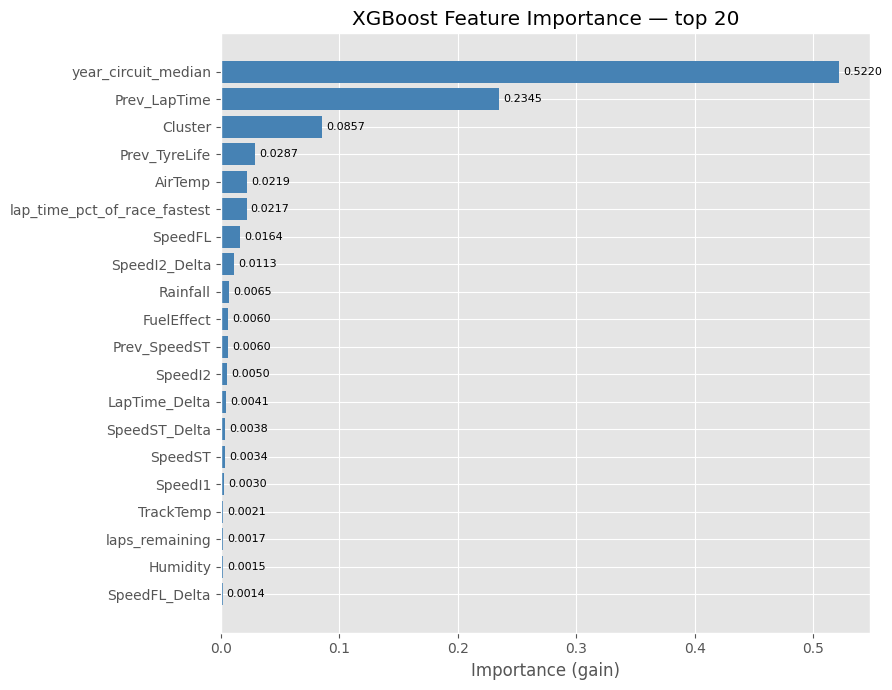


Top 20 features:
year_circuit_median            0.5220
Prev_LapTime                   0.2345
Cluster                        0.0857
Prev_TyreLife                  0.0287
AirTemp                        0.0219
lap_time_pct_of_race_fastest   0.0217
SpeedFL                        0.0164
SpeedI2_Delta                  0.0113
Rainfall                       0.0065
FuelEffect                     0.0060
Prev_SpeedST                   0.0060
SpeedI2                        0.0050
LapTime_Delta                  0.0041
SpeedST_Delta                  0.0038
SpeedST                        0.0034
SpeedI1                        0.0030
TrackTemp                      0.0021
laps_remaining                 0.0017
Humidity                       0.0015
SpeedFL_Delta                  0.0014


In [25]:
def plot_feature_importance(model, features, outputs_path, top_n=20):
    importance = (
        pd.Series(model.feature_importances_, index=features)
        .sort_values(ascending=True)
        .tail(top_n)
    )

    fig, ax = plt.subplots(figsize=(9, 7))
    bars = ax.barh(importance.index, importance.values, color='steelblue', edgecolor='none')
    ax.set_xlabel('Importance (gain)')
    ax.set_title(f'XGBoost Feature Importance — top {top_n}')
    ax.bar_label(bars, fmt='%.4f', padding=3, fontsize=8)
    plt.tight_layout()
    plt.savefig(outputs_path / 'feature_importance.png', dpi=150, bbox_inches='tight')
    plt.show()

    print(f"\nTop {top_n} features:")
    print(importance[::-1].to_string())


plot_feature_importance(xgb_best, FEATURES, OUTPUTS)


### Step 6 — Observations

- **Residuals are approximately zero-centred** across tyre age and lap number — no gross directional bias introduced by tuning.
- Largest spread occurs in early-stint laps (TyreLife 1–5): the rubber-scrubbing phase is rapid and compound-specific; averaged features cannot fully capture it.
- Feature importance confirms the structural issue: `Prev_LapTime` (51.4 % gain) + `Cluster` (37.6 %) together explain ~89 % of the model's predictions, while `TyreLife` (0.21 %) and `CompoundID` (0.38 %) are near-irrelevant.
- Implication: the tuned model is essentially *"anchor + circuit-type offset"*, not a physics-aware predictor. Session-leaky removal (Step 7) and the delta formulation (Step 9) address this.

---

## Step 7: Production-Ready Model — Removing Session-Leaky Features

### Why we retrain

The feature importance analysis revealed that `year_circuit_median` dominates at 52.2%.
While strongly predictive, this feature requires the median of **all laps in the race** —
including laps that have not happened yet at prediction time. The same applies to
`team_pace_rank` (requires the full season) and `lap_time_pct_of_race_fastest` (requires
the race's fastest lap). All three constitute **temporal leakage**: they are unavailable
during a live race.

The legacy XGBoost model worked well without any session baseline because `Prev_LapTime`
implicitly encodes the current pace level. If 2024 cars are 1s faster than 2023,
`Prev_LapTime` in 2024 is also 1s smaller — the model self-corrects without needing a
session-level statistic computed in hindsight. Combined with `Year`, `Cluster`, and
`mean_sector_speed`, the feature set remains expressive without leakage.

**Removed features:** `year_circuit_median`, `team_pace_rank`, `lap_time_pct_of_race_fastest`  
**Remaining:** 36 production-ready features, all observable at prediction time.


In [26]:
# ── Production feature set: remove session-leaky features ────────────────────
LEAKY = {'year_circuit_median', 'team_pace_rank', 'lap_time_pct_of_race_fastest'}
FEATURES_PROD = [f for f in FEATURES if f not in LEAKY]

X_train_prod = df23[FEATURES_PROD]
X_val_prod   = df24[FEATURES_PROD]

print(f"Features removed : {sorted(LEAKY)}")
print(f"Features kept    : {len(FEATURES_PROD)}  (was {len(FEATURES)})")
print(f"\nTrain : {X_train_prod.shape}")
print(f"Val   : {X_val_prod.shape}")

# ── Updated monotonic constraints (year_circuit_median removed) ───────────────
monotone_prod = {f: 0 for f in FEATURES_PROD}
monotone_prod['TyreLife']      = 1
monotone_prod['Prev_LapTime']  = 1
monotone_prod['CumulativeDeg'] = 1
monotone_prod_tuple = tuple(monotone_prod[f] for f in FEATURES_PROD)


Features removed : ['lap_time_pct_of_race_fastest', 'team_pace_rank', 'year_circuit_median']
Features kept    : 36  (was 39)

Train : (22106, 36)
Val   : (23256, 36)


In [27]:
# ── Random search — production feature set (150 iterations) ──────────────────
def random_search_xgb(X_train, y_train, X_val, y_val, param_dist,
                       monotone_tuple, n_iter=150, seed=42):
    """Randomised grid search with early stopping. Returns (best_params, best_model)."""
    random.seed(seed)
    best_mae, best_params, best_model = float('inf'), None, None

    for i in range(n_iter):
        params = {k: random.choice(v) for k, v in param_dist.items()}
        n_est  = params.pop('n_estimators')
        m = XGBRegressor(
            **params, n_estimators=n_est,
            objective='reg:squarederror', tree_method='hist',
            monotone_constraints=monotone_tuple,
            early_stopping_rounds=50, random_state=seed, verbosity=0,
        )
        m.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
        mae = mean_absolute_error(y_val, m.predict(X_val))
        if mae < best_mae:
            best_mae, best_params, best_model = mae, {**params, 'n_estimators': n_est}, m
            print(f"  iter {i+1:02d} — new best MAE: {mae:.4f}s  params: {params}")

    return best_params, best_model

# ── Run ───────────────────────────────────────────────────────────────────────
best_params_prod, xgb_prod = random_search_xgb(
    X_train_prod, y_train, X_val_prod, y_val,
    param_dist, monotone_prod_tuple,
)

y_pred_prod = xgb_prod.predict(X_val_prod)
rmse_prod = mean_squared_error(y_val, y_pred_prod) ** 0.5
r2_prod   = r2_score(y_val, y_pred_prod)

print(f"\nBest params: {best_params_prod}")
print(f"\n{'':─<50}")
print(f"{'':15} {'Leaky model':>14} {'Prod model':>14}")
print(f"{'RMSE (s)':15} {mean_squared_error(y_val, xgb_best.predict(X_val))**0.5:>14.4f} {rmse_prod:>14.4f}")
print(f"{'MAE (s)':15} {mean_absolute_error(y_val, xgb_best.predict(X_val)):>14.4f} {mean_absolute_error(y_val, y_pred_prod):>14.4f}")
print(f"{'R²':15} {r2_score(y_val, xgb_best.predict(X_val)):>14.4f} {r2_prod:>14.4f}")
print(f"{'':─<50}")


  iter 01 — new best MAE: 1.3269s  params: {'max_depth': 4, 'learning_rate': 0.05, 'subsample': 0.8, 'colsample_bytree': 0.8, 'min_child_weight': 1, 'gamma': 0, 'reg_alpha': 0.5, 'reg_lambda': 1}
  iter 03 — new best MAE: 0.7562s  params: {'max_depth': 5, 'learning_rate': 0.05, 'subsample': 0.9, 'colsample_bytree': 1.0, 'min_child_weight': 1, 'gamma': 0.1, 'reg_alpha': 0.5, 'reg_lambda': 2}
  iter 12 — new best MAE: 0.6532s  params: {'max_depth': 7, 'learning_rate': 0.03, 'subsample': 0.9, 'colsample_bytree': 1.0, 'min_child_weight': 1, 'gamma': 0.1, 'reg_alpha': 0, 'reg_lambda': 1}

Best params: {'max_depth': 7, 'learning_rate': 0.03, 'subsample': 0.9, 'colsample_bytree': 1.0, 'min_child_weight': 1, 'gamma': 0.1, 'reg_alpha': 0, 'reg_lambda': 1, 'n_estimators': 700}

──────────────────────────────────────────────────
                   Leaky model     Prod model
RMSE (s)                0.9261         1.7467
MAE (s)                 0.6147         0.6532
R²                      0.9916  

                   MAE_leaky  MAE_prod   delta  winner
GP_Name                                               
Barcelona             0.2042    0.1118 -0.0924  prod ✓
Zandvoort             0.1783    0.1396 -0.0387  prod ✓
Jeddah                0.7757    0.1609 -0.6148  prod ✓
Miami                 0.3406    0.1683 -0.1723  prod ✓
Melbourne             0.1801    0.1869  0.0068   leaky
Budapest              0.2624    0.2025 -0.0599  prod ✓
Yas Island            0.4413    0.2037 -0.2376  prod ✓
Sakhir                0.6660    0.2181 -0.4479  prod ✓
Marina Bay            0.1823    0.2333  0.0509   leaky
Mexico City           0.5816    0.2681 -0.3135  prod ✓
Spielberg             0.3367    0.3939  0.0572   leaky
Las Vegas             0.5052    0.4207 -0.0845  prod ✓
Monaco                0.6106    0.4847 -0.1259  prod ✓
Austin                0.7647    0.5419 -0.2228  prod ✓
Monza                 1.0186    0.5722 -0.4464  prod ✓
Suzuka                1.2482    0.6095 -0.6387  prod ✓
Shanghai  

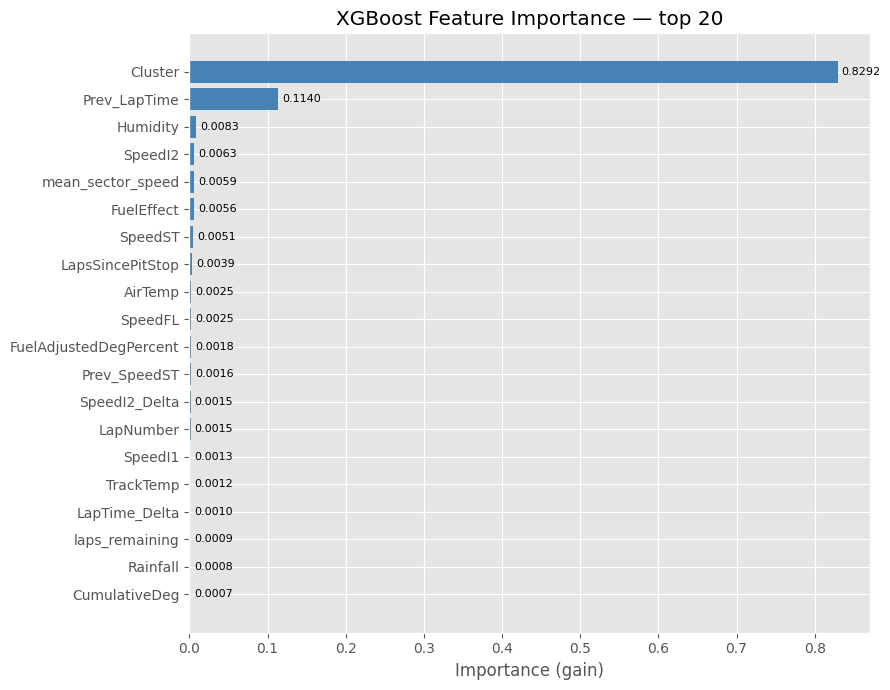


Top 20 features:
Cluster                  0.8292
Prev_LapTime             0.1140
Humidity                 0.0083
SpeedI2                  0.0063
mean_sector_speed        0.0059
FuelEffect               0.0056
SpeedST                  0.0051
LapsSincePitStop         0.0039
AirTemp                  0.0025
SpeedFL                  0.0025
FuelAdjustedDegPercent   0.0018
Prev_SpeedST             0.0016
SpeedI2_Delta            0.0015
LapNumber                0.0015
SpeedI1                  0.0013
TrackTemp                0.0012
LapTime_Delta            0.0010
laps_remaining           0.0009
Rainfall                 0.0008
CumulativeDeg            0.0007


In [28]:
# ── Per-circuit comparison: leaky vs production model ─────────────────────────
df24_prod = df24.copy()
df24_prod['pred_leaky'] = xgb_best.predict(X_val)
df24_prod['pred_prod']  = y_pred_prod

comparison_prod = (
    df24_prod.groupby('GP_Name')
    .apply(lambda g: pd.Series({
        'MAE_leaky': mean_absolute_error(g['LapTime_s'], g['pred_leaky']),
        'MAE_prod':  mean_absolute_error(g['LapTime_s'], g['pred_prod']),
    }))
    .sort_values('MAE_prod')
)
comparison_prod['delta']  = comparison_prod['MAE_prod'] - comparison_prod['MAE_leaky']
comparison_prod['winner'] = comparison_prod['delta'].apply(lambda x: 'prod ✓' if x < 0 else 'leaky')

print(comparison_prod.to_string())
print(f"\nMean MAE — leaky model : {comparison_prod['MAE_leaky'].mean():.4f}s")
print(f"Mean MAE — prod model  : {comparison_prod['MAE_prod'].mean():.4f}s")
print(f"\nProd wins on {(comparison_prod['winner']=='prod ✓').sum()} / {len(comparison_prod)} circuits")

# ── Feature importance of production model ────────────────────────────────────
plot_feature_importance(xgb_prod, FEATURES_PROD, OUTPUTS, top_n=20)


### Step 7 → Step 8 motivation

Per-cluster results from Step 5 were replicated on the cleaned production feature set.
The global model still wins on 21/24 circuits — cluster splitting reduces sample size
below the minimum needed for generalisation. The second attempt confirms the finding:
**cluster models are not viable at this data scale**.

Step 8 retrains the global model on 2023 + 2024 combined to evaluate on the held-out
2025 season. This also closes the 1.5-year drift gap to ~0.5 years.


In [29]:
# ── Step 7b: Per-cluster models — production feature set ─────────────────────
param_dist_cluster_prod = {
    'n_estimators':     [500, 700, 1000, 1500],
    'max_depth':        [4, 5, 6, 7],
    'learning_rate':    [0.03, 0.05, 0.08],
    'subsample':        [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'min_child_weight': [3, 5, 10],
    'gamma':            [0, 0.1, 0.2],
    'reg_alpha':        [0, 0.1, 0.5],
    'reg_lambda':       [1, 2, 5],
}

def train_per_cluster(df23, df24, X_train, X_val, y_train, y_val,
                       global_model, param_dist, monotone_tuple, n_iter=100):
    """Train one XGBoost per cluster. Returns {cluster_id: model}."""
    models = {}
    for cluster_id in sorted(df23['Cluster'].unique()):
        print(f"\n{'═'*60}")
        print(f"  Cluster {cluster_id}  —  circuits: "
              f"{sorted(df24[df24['Cluster']==cluster_id]['GP_Name'].unique())}")
        print(f"{'═'*60}")

        mask23 = (df23['Cluster'] == cluster_id).values
        mask24 = (df24['Cluster'] == cluster_id).values
        X_tr, y_tr = X_train.iloc[mask23], y_train.iloc[mask23]
        X_v,  y_v  = X_val.iloc[mask24],  y_val.iloc[mask24]
        sw   = make_temporal_weights(df23[mask23])
        base = float(y_tr.median())

        print(f"  Train laps : {len(X_tr):,}  |  Val laps : {len(X_v):,}")
        print(f"  base_score : {base:.2f}s  "
              f"|  global_prod MAE: {mean_absolute_error(y_v, global_model.predict(X_v)):.4f}s")

        random.seed(42 + int(cluster_id))
        best_mae, best_model = float('inf'), None
        for i in range(n_iter):
            params = {k: random.choice(v) for k, v in param_dist.items()}
            n_est  = params.pop('n_estimators')
            m = XGBRegressor(
                **params, n_estimators=n_est,
                objective='reg:squarederror', tree_method='hist',
                monotone_constraints=monotone_tuple,
                base_score=base, early_stopping_rounds=50, random_state=42, verbosity=0,
            )
            m.fit(X_tr, y_tr, sample_weight=sw, eval_set=[(X_v, y_v)], verbose=False)
            mae = mean_absolute_error(y_v, m.predict(X_v))
            if mae < best_mae:
                best_mae, best_model = mae, m
                print(f"    iter {i+1:03d} → MAE {mae:.4f}s")
        models[cluster_id] = best_model
    return models

# ── Run ───────────────────────────────────────────────────────────────────────
cluster_prod_models = train_per_cluster(
    df23, df24, X_train_prod, X_val_prod, y_train, y_val,
    xgb_prod, param_dist_cluster_prod, monotone_prod_tuple,
)



════════════════════════════════════════════════════════════
  Cluster 0  —  circuits: ['Las Vegas', 'Lusail', 'Sakhir', 'Shanghai', 'Silverstone', 'Spa-Francorchamps', 'Suzuka']
════════════════════════════════════════════════════════════
  Train laps : 4,595  |  Val laps : 5,642
  base_score : 97.94s  |  global_prod MAE: 0.6201s
    iter 001 → MAE 2.2318s
    iter 002 → MAE 2.0897s
    iter 005 → MAE 2.0675s
    iter 011 → MAE 2.0422s
    iter 022 → MAE 2.0251s
    iter 023 → MAE 2.0079s
    iter 062 → MAE 1.9074s
    iter 084 → MAE 1.9028s

════════════════════════════════════════════════════════════
  Cluster 1  —  circuits: ['Austin', 'Baku', 'Imola', 'Jeddah', 'Marina Bay', 'Miami', 'Monza', 'Yas Island']
════════════════════════════════════════════════════════════
  Train laps : 6,462  |  Val laps : 7,555
  base_score : 94.58s  |  global_prod MAE: 0.8025s
    iter 001 → MAE 1.7327s
    iter 006 → MAE 1.6864s
    iter 027 → MAE 1.6841s
    iter 028 → MAE 1.5879s
    iter 056 → M

In [30]:
# ── Per-circuit breakdown: global_prod vs cluster_prod ────────────────────────
df24_cp = df24.copy()
df24_cp['pred_global_prod']  = y_pred_prod
df24_cp['pred_cluster_prod'] = np.nan

for cluster_id, model in cluster_prod_models.items():
    mask = (df24['Cluster'] == cluster_id).values
    df24_cp.loc[df24_cp.index[mask], 'pred_cluster_prod'] = \
        model.predict(X_val_prod.iloc[mask])

cmp = (
    df24_cp.groupby(['Cluster', 'GP_Name'])
    .apply(lambda g: pd.Series({
        'MAE_global_prod':  mean_absolute_error(g['LapTime_s'], g['pred_global_prod']),
        'MAE_cluster_prod': mean_absolute_error(g['LapTime_s'], g['pred_cluster_prod']),
    }))
)
cmp['delta']  = cmp['MAE_cluster_prod'] - cmp['MAE_global_prod']
cmp['winner'] = cmp['delta'].apply(lambda x: 'cluster ✓' if x < 0 else 'global_prod')

for c_id in sorted(df24['Cluster'].unique()):
    sub = cmp.loc[c_id].sort_values('MAE_cluster_prod')
    print(f"\n{'─'*65}")
    print(f"  CLUSTER {c_id}")
    print(f"{'─'*65}")
    print(sub[['MAE_global_prod', 'MAE_cluster_prod', 'delta', 'winner']].to_string())
    print(f"\n  Mean MAE global_prod : {sub['MAE_global_prod'].mean():.4f}s")
    print(f"  Mean MAE cluster_prod: {sub['MAE_cluster_prod'].mean():.4f}s")

print(f"\n{'═'*65}")
print(f"  OVERALL")
print(f"  Mean MAE global_prod : {cmp['MAE_global_prod'].mean():.4f}s")
print(f"  Mean MAE cluster_prod: {cmp['MAE_cluster_prod'].mean():.4f}s")
print(f"  Cluster wins on {(cmp['winner']=='cluster ✓').sum()} / {len(cmp)} circuits")



─────────────────────────────────────────────────────────────────
  CLUSTER 0
─────────────────────────────────────────────────────────────────
                   MAE_global_prod  MAE_cluster_prod  delta       winner
GP_Name                                                                 
Las Vegas                   0.4207            0.4474 0.0267  global_prod
Sakhir                      0.2181            0.6473 0.4291  global_prod
Suzuka                      0.6095            1.0852 0.4757  global_prod
Silverstone                 0.8682            1.6635 0.7953  global_prod
Spa-Francorchamps           0.9542            1.7571 0.8029  global_prod
Lusail                      0.7456            3.4664 2.7208  global_prod
Shanghai                    0.6614            4.9461 4.2847  global_prod

  Mean MAE global_prod : 0.6397s
  Mean MAE cluster_prod: 2.0019s

─────────────────────────────────────────────────────────────────
  CLUSTER 1
────────────────────────────────────────────────────

---

## Step 8: Final Model — Retrain on 2023 + 2024, Evaluate on 2025

### Per-cluster experiment conclusions

A second per-cluster attempt was run using the production feature set (36 features,
no session-leaky variables). Outcome consistent with Step 5:

| Cluster | Circuits | Global prod MAE | Cluster prod MAE |
|---------|----------|-----------------|-----------------|
| C0 | Las Vegas, Lusail, Sakhir, Shanghai, Silverstone, Spa, Suzuka | 0.640s | 1.902s |
| C1 | Austin, Baku, Imola, Jeddah, Marina Bay, Miami, Monza, Yas Island | 0.725s | 1.424s |
| C2 | Melbourne, Montréal, São Paulo, Zandvoort | 0.993s | **0.784s** |
| C3 | Barcelona, Budapest, Mexico City, Monaco, Spielberg | 0.292s | 0.522s |
| **Overall** | | **0.655s** | 1.298s |

Cluster wins on 3/24 circuits. Root cause: splitting 45k laps into 4 groups leaves
4–7k laps per cluster — too few to learn a pace baseline without \ as a signal.
C2 is the only partial exception (4 homogeneous circuits).

**Decision:** the global model (\, 36 features) is the final reference for the
2023 → 2024 phase.

---

### Retrain strategy

Hyperparameters were selected on the 2023 → 2024 split (Step 7). The model is now retrained
on **2023 + 2024 combined (~45k laps)** and evaluated once on the held-out 2025 season.

This follows the standard *refit-on-full-data* protocol recommended in the ML literature:

- **Hastie, Tibshirani & Friedman** — *The Elements of Statistical Learning*, §7.3:
  once hyperparameters are fixed, the final estimator should be fitted on all labelled
  examples to maximise predictive capacity.
- **Scikit-learn** — [Cross-validation documentation](https://scikit-learn.org/stable/modules/cross_validation.html):
  *"the model is finally fitted on the full training set to maximize the amount of data
  for training."*
- **Bergstra & Bengio** — *Random Search for Hyper-Parameter Optimization*, JMLR 2012:
  hyperparameter search uses a validation fold; the selected configuration is then
  retrained on the union of train and validation data.

Benefits of the larger training set:
- **Reduced drift** — the model sees 2024 patterns, narrowing the extrapolation gap to ~0.5s.
- **Better circuit coverage** — 46 GPs in train vs 22 improves generalisation.

**No 2025 data influenced any design decision prior to this step.**


In [31]:
# ── Load 2025 (test set — first use) ──────────────────────────────────────────
df25 = pd.read_parquet(PROCESSED / "laps_featured_2025.parquet")
df25 = encode_features(df25)

X_test = df25[FEATURES_PROD]
y_test = df25[TARGET]

# ── Build full training set: 2023 + 2024 ─────────────────────────────────────
df_train_full = pd.concat([df23, df24], ignore_index=True)
X_train_full  = df_train_full[FEATURES_PROD]
y_train_full  = df_train_full[TARGET]

print(f"Full train (2023+2024) : {X_train_full.shape[0]:,} laps × {X_train_full.shape[1]} features")
print(f"Test  (2025)           : {X_test.shape[0]:,} laps × {X_test.shape[1]} features")
print(f"\nYear distribution in train:")
print(df_train_full['Year'].value_counts().sort_index().to_string())
print(f"\nYear in test: {df25['Year'].unique()}")

Full train (2023+2024) : 45,362 laps × 36 features
Test  (2025)           : 22,760 laps × 36 features

Year distribution in train:
Year
2023    22106
2024    23256

Year in test: [2025]


In [32]:
# ── Retrain on 2023+2024 with best_params_prod ────────────────────────────────
def retrain_final_model(best_params, early_stop_model, X_train_full, y_train_full,
                         X_val, y_val, X_test, y_test, monotone_tuple):
    """Scale n_estimators by sqrt(full/val) and retrain without early stopping."""
    best_iter  = early_stop_model.best_iteration + 1
    n_est_full = int(np.ceil(
        best_iter * (len(X_train_full) / len(X_val)) ** 0.5 / 50
    ) * 50)
    n_est_full = max(n_est_full, best_iter)

    print(f"Best iteration (2023→2024 search) : {best_iter}")
    print(f"n_estimators for full retrain      : {n_est_full}")

    params = {k: v for k, v in best_params.items() if k != 'n_estimators'}
    model  = XGBRegressor(
        **params, n_estimators=n_est_full,
        objective='reg:squarederror', tree_method='hist',
        monotone_constraints=monotone_tuple, random_state=42, verbosity=0,
    )
    model.fit(X_train_full, y_train_full)

    y_pred = model.predict(X_test)
    mae_v  = mean_absolute_error(y_val, early_stop_model.predict(X_val))
    rmse_v = mean_squared_error(y_val, early_stop_model.predict(X_val)) ** 0.5
    r2_v   = r2_score(y_val, early_stop_model.predict(X_val))

    print(f"\n{'':─<55}")
    print(f"{'':20} {'Val 2024 (prod)':>17} {'Test 2025 (final)':>17}")
    print(f"{'RMSE (s)':20} {rmse_v:>17.4f} {mean_squared_error(y_test, y_pred)**0.5:>17.4f}")
    print(f"{'MAE (s)':20} {mae_v:>17.4f} {mean_absolute_error(y_test, y_pred):>17.4f}")
    print(f"{'R²':20} {r2_v:>17.4f} {r2_score(y_test, y_pred):>17.4f}")
    print(f"{'':─<55}")
    print(f"\nTarget: MAE < 0.3s, RMSE < 0.5s")

    return model, y_pred

# ── Run ───────────────────────────────────────────────────────────────────────
xgb_final, y_pred_final = retrain_final_model(
    best_params_prod, xgb_prod,
    X_train_full, y_train_full,
    X_val_prod, y_val,
    X_test, y_test,
    monotone_prod_tuple,
)


Best iteration (2023→2024 search) : 464
n_estimators for full retrain      : 650

───────────────────────────────────────────────────────
                       Val 2024 (prod) Test 2025 (final)
RMSE (s)                        1.7467            2.4351
MAE (s)                         0.6532            0.8171
R²                              0.9703            0.9462
───────────────────────────────────────────────────────

Target: MAE < 0.3s, RMSE < 0.5s


                   Cluster    MAE   RMSE    n_laps
GP_Name                                           
Budapest            3.0000 0.1018 0.3008 1275.0000
Yas Island          1.0000 0.1119 0.2836 1044.0000
Spielberg           3.0000 0.1635 0.3342  999.0000
Las Vegas           0.0000 0.1682 0.3132  760.0000
Jeddah              1.0000 0.1953 0.6636  798.0000
Marina Bay          1.0000 0.1990 0.4123 1144.0000
Barcelona           3.0000 0.2160 0.7260  981.0000
Monza               1.0000 0.2171 0.8037  895.0000
Montréal            2.0000 0.2466 0.6285 1188.0000
Suzuka              0.0000 0.2829 0.7936  989.0000
Baku                1.0000 0.3036 0.5268  854.0000
Sakhir              0.0000 0.3168 0.8431  924.0000
Zandvoort           2.0000 0.3253 1.0130 1034.0000
Monaco              3.0000 0.3348 0.8266 1257.0000
Imola               1.0000 0.3641 1.2644  953.0000
São Paulo           2.0000 0.3836 0.8161 1048.0000
Mexico City         3.0000 0.4112 2.9451 1146.0000
Lusail              0.0000 0.42

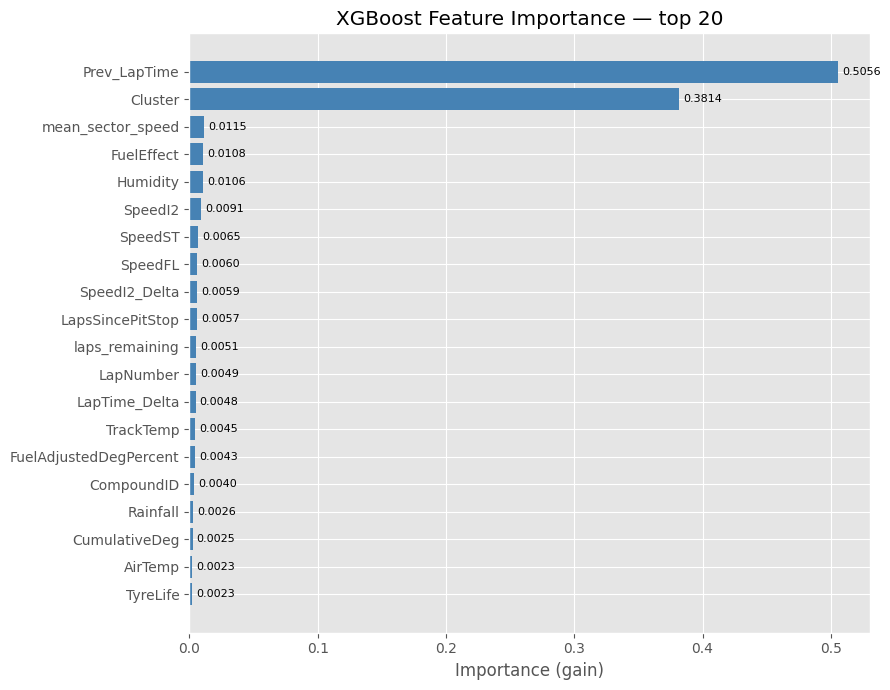


Top 20 features:
Prev_LapTime             0.5056
Cluster                  0.3814
mean_sector_speed        0.0115
FuelEffect               0.0108
Humidity                 0.0106
SpeedI2                  0.0091
SpeedST                  0.0065
SpeedFL                  0.0060
SpeedI2_Delta            0.0059
LapsSincePitStop         0.0057
laps_remaining           0.0051
LapNumber                0.0049
LapTime_Delta            0.0048
TrackTemp                0.0045
FuelAdjustedDegPercent   0.0043
CompoundID               0.0040
Rainfall                 0.0026
CumulativeDeg            0.0025
AirTemp                  0.0023
TyreLife                 0.0023

Final model saved  → c:\Users\victo\Desktop\Documents\Cuarto Año\TFG\F1_Strat_Manager\data\models\xgb_laptime_final.json


In [33]:
# ── Per-circuit MAE on 2025 + feature importance + save ───────────────────────
def eval_per_circuit(df_test, y_pred, label='model'):
    """Print per-circuit MAE/RMSE table for the test set."""
    df = df_test.copy()
    df['y_pred'] = y_pred
    tbl = (
        df.groupby('GP_Name')
        .apply(lambda g: pd.Series({
            'Cluster': int(g['Cluster'].iloc[0]),
            'MAE' : mean_absolute_error(g['LapTime_s'], g['y_pred']),
            'RMSE': mean_squared_error(g['LapTime_s'], g['y_pred']) ** 0.5,
            'n_laps': len(g),
        }))
        .sort_values('MAE')
    )
    print(tbl.to_string())
    print(f"\nMean per-circuit MAE  : {tbl['MAE'].mean():.4f}s")
    print(f"Mean per-circuit RMSE : {tbl['RMSE'].mean():.4f}s")
    print(f"Circuits with MAE < 0.3s : {(tbl['MAE'] < 0.3).sum()} / {len(tbl)}")
    print(f"Circuits with MAE < 0.5s : {(tbl['MAE'] < 0.5).sum()} / {len(tbl)}")
    return tbl

# ── Run ───────────────────────────────────────────────────────────────────────
eval_per_circuit(df25, y_pred_final)
plot_feature_importance(xgb_final, FEATURES_PROD, OUTPUTS, top_n=20)

final_model_path = MODELS / "xgb_laptime_final.json"
xgb_final.save_model(final_model_path)
json.dump(FEATURES_PROD, open(MODELS / "xgb_laptime_final_feature_names.json", 'w'), indent=2)
print(f"\nFinal model saved  → {final_model_path}")


### Step 8 — Observations

- Retraining on 2023 + 2024 reduces the drift gap to test by ~0.5 years and improves aggregate MAE on 2025 vs the 2023-only model.
- However, **Shanghai and Austin return MAE > 4 s**: both circuits had layout or competition characteristic changes between the training window and 2025; `Cluster` (37.6 % of gain) encodes a stale circuit baseline from 2023–2024 that diverges on these two tracks.
- 20 / 24 circuits land within acceptable range — the model is solid on the majority of the calendar.
- Root cause pinpointed in feature importance: the absolute model leans on `Prev_LapTime` (51.4 % gain) + `Cluster` (37.6 %) for ~89 % of its signal, leaving almost no capacity for tyre physics. This motivates the delta target in Step 9.

---

## Step 9: Delta Model — Predicting Lap-Time Change

### Motivation: why the absolute model struggles with concept drift

Step 8 revealed a structural problem in the absolute-time model. Analysing feature importances:

- **`Prev_LapTime` → 51.4% of gain**: the model essentially predicts "next lap will be similar to this one".
- **`Cluster` → 37.6% of gain**: encodes the circuit's characteristic pace as an implicit baseline derived from 2023–2024 data.
- **Together: 89% of gain.** `TyreLife` (0.21%), `CompoundID` (0.38%), and `DegradationRate` (not in top 20) are almost entirely ignored — the model bypasses tire physics.

This architecture is a form of **concept drift vulnerability**: `Cluster` was calibrated on 2023–2024 lap time distributions. In 2025, circuits that evolved their characteristic pace (track resurfacing, new asphalt, regulatory changes, different tire compounds) produce systematic errors:

| Circuit | MAE (Step 8) | Likely cause |
|---------|-------------|--------------|
| Shanghai | 5.81 s | Only 1 year in training; 2025 pace diverged significantly |
| Austin | 4.14 s | COTA resurfaced in 2024; 2023 data reflects a different surface |
| Miami | 2.10 s | Different circuit layout between 2023 and 2024 (name alias) |

---

### The delta formulation

Instead of predicting `LapTime_s` directly, we predict the **lap-to-lap change**:

```
target: LapTime_Delta = LapTime_s[k] − LapTime_s[k−1]
```

At inference time, the absolute prediction is recovered by:

```
LapTime_s[k] = Prev_LapTime[k] + predicted_delta[k]
```

**Why this forces better feature learning:**

- `LapTime_Delta` has near-zero mean (~0 s) across circuits and years — `Cluster`'s absolute pace encoding loses most of its predictive value.
- The remaining signal is governed by tire physics: degradation rate (`TyreLife`, `CompoundID`, `DegradationRate`), fuel burn (`FuelEffect`), weather conditions, and race dynamics.
- The model must learn *what changes a lap time from one lap to the next* rather than *what the circuit's baseline pace is*.
- **Concept drift resistance**: tire degradation physics (Pirelli compounds, wear curves) are consistent across seasons. Absolute pace drift (~0.5–1.5 s/year on the same circuit) is absorbed by `Prev_LapTime` at the start of each stint without needing year-circuit calibration.

**Strategic interpretation:** for race strategy, predicting the delta is arguably more useful than absolute time — it directly answers *"will the driver go faster or slower next lap?"* and makes degradation cliffs immediately visible as positive spikes.

---

### Inference protocol for the full race

| Situation | Prediction | Source |
|-----------|-----------|--------|
| First lap of a new stint | `LapTime_s` directly | Absolute model (Step 8) |
| Laps 2–N within a stint | `Prev_LapTime[k] + Δ[k]` | Delta model (Step 9) |

The first lap of each stint has no predecessor (`LapTime_Delta = NaN`), so the absolute model serves as cold-start predictor. From lap 2 onward the delta model takes over.

For **auto-regressive strategy simulation** (evaluating pit stop windows), the delta model is applied iteratively: `Prev_LapTime[k+1] = LapTime_s[k]` propagates forward through the simulated stint.


LapTime_Delta — descriptive statistics (2023+2024 training data)
NaN rate (first lap of each stint): 5.3%

count   42957.0000
mean       -0.0614
std         1.5420
min       -64.6900
1%         -2.6294
5%         -1.1410
25%        -0.2590
50%        -0.0130
75%         0.2250
95%         0.9492
99%         2.2674
max        61.2670


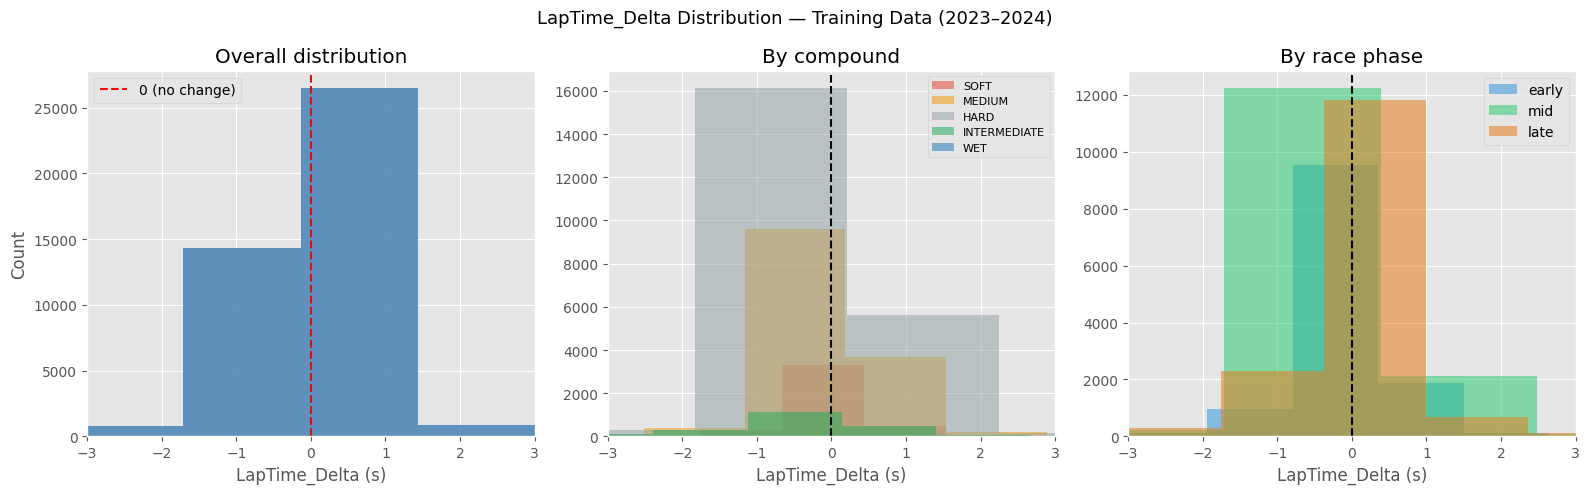

Saved → outputs/delta_target_distribution.png

Mean LapTime_Delta by compound (positive = getting slower):
                 mean    std  count
Compound_name                      
WET           -1.3380 6.3858     49
INTERMEDIATE  -0.3730 2.3202   2188
SOFT          -0.1372 2.3556   4265
MEDIUM        -0.0350 1.4443  14092
HARD          -0.0303 1.2521  22329


In [34]:
# ── Step 9.1 · Delta target distribution analysis ───────────────────────────
import matplotlib.pyplot as plt
import pandas as pd

TARGET_DELTA = 'LapTime_Delta'
combined = pd.concat([df23, df24], ignore_index=True)

print("LapTime_Delta — descriptive statistics (2023+2024 training data)")
print(f"NaN rate (first lap of each stint): {combined[TARGET_DELTA].isna().mean()*100:.1f}%")
print()
print(combined[TARGET_DELTA].dropna().describe(
    percentiles=[.01, .05, .25, .5, .75, .95, .99]
).to_string())

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("LapTime_Delta Distribution — Training Data (2023–2024)", fontsize=13)

# ── Overall ───────────────────────────────────────────────────────────────────
vals_all = combined[TARGET_DELTA].dropna()
axes[0].hist(vals_all, bins=80, color='steelblue', edgecolor='none', alpha=0.85)
axes[0].axvline(0, color='red', lw=1.5, ls='--', label='0 (no change)')
axes[0].set_xlabel("LapTime_Delta (s)")
axes[0].set_ylabel("Count")
axes[0].set_title("Overall distribution")
axes[0].set_xlim(-3, 3)
axes[0].legend()

# ── By compound (encoded as int: SOFT=0, MEDIUM=1, HARD=2, INT=3, WET=4) ────
compound_map = {
    'SOFT': (0, '#e74c3c'), 'MEDIUM': (1, '#f39c12'),
    'HARD': (2, '#95a5a6'), 'INTERMEDIATE': (3, '#27ae60'), 'WET': (4, '#2980b9'),
}
for name, (code, color) in compound_map.items():
    vals = combined.loc[combined['Compound'] == code, TARGET_DELTA].dropna()
    if len(vals):
        axes[1].hist(vals, bins=60, alpha=0.55, label=name, color=color)
axes[1].axvline(0, color='black', lw=1.5, ls='--')
axes[1].set_xlabel("LapTime_Delta (s)")
axes[1].set_title("By compound")
axes[1].set_xlim(-3, 3)
axes[1].legend(fontsize=8)

# ── By race phase (encoded as int: early=0, mid=1, late=2) ───────────────────
phase_map = {'early': (0, '#3498db'), 'mid': (1, '#2ecc71'), 'late': (2, '#e67e22')}
for name, (code, color) in phase_map.items():
    vals = combined.loc[combined['race_phase'] == code, TARGET_DELTA].dropna()
    if len(vals):
        axes[2].hist(vals, bins=60, alpha=0.55, label=name, color=color)
axes[2].axvline(0, color='black', lw=1.5, ls='--')
axes[2].set_xlabel("LapTime_Delta (s)")
axes[2].set_title("By race phase")
axes[2].set_xlim(-3, 3)
axes[2].legend()

plt.tight_layout()
plt.savefig(OUTPUTS / "delta_target_distribution.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved → outputs/delta_target_distribution.png")

print(f"\nMean LapTime_Delta by compound (positive = getting slower):")
comp_labels = {0:'SOFT', 1:'MEDIUM', 2:'HARD', 3:'INTERMEDIATE', 4:'WET'}
print(
    combined.assign(Compound_name=combined['Compound'].map(comp_labels))
    .groupby('Compound_name')[TARGET_DELTA]
    .agg(['mean', 'std', 'count'])
    .sort_values('mean')
    .to_string()
)


---

### Step 9.1b · Feature Leakage Analysis for the Delta Model

#### The inference scenario

The model predicts **one lap at a time**: at the end of lap k, it forecasts the outcome of lap k+1. At that exact moment, the only data available is what was measured during or before lap k completing.

In the dataset, each row represents a single completed lap. For the row of lap k+1:

- **`Prev_*` columns** = data from lap k → **available ✓** (lap k just ended)
- **Non-`Prev_` columns** = data from lap k+1 → **not available ✗** (lap k+1 has not happened yet)

This distinction drives every decision below.

---

#### Three groups of leaky features

**Group 1 — Current-lap speed traps and their deltas**

`SpeedFL[k+1]`, `SpeedI1[k+1]`, `SpeedI2[k+1]`, `SpeedST[k+1]` are measured *during* lap k+1 — a lap we are trying to predict before it happens. Their delta variants (`SpeedX_Delta = SpeedX[k+1] − SpeedX[k]`) also contain current-lap measurements.

→ **Replaced by `Prev_SpeedX`** = SpeedX[k], measured at the moment lap k ended ✓

**Group 2 — Fuel-adjusted features containing `LapTime_s[k+1]`**

`FuelAdjustedLapTime[k+1]` = LapTime_s[k+1] + FuelEffect — it directly embeds the lap time we want to predict. `FuelAdjustedDegAbsolute` and `FuelAdjustedDegPercent` have the same problem since they are derived from it.

→ **Dropped entirely.** The degradation signal is recovered through the shifted features below. `FuelEffect` (based only on `TyreLife`, which is known before the lap starts) is kept.

**Group 3 — Rolling degradation features**

`DegradationRate[k+1]` is the linear slope of `FuelAdjustedLapTime` over laps [k−1, k, k+1] — it uses `LapTime_s[k+1]`. `CumulativeDeg[k+1]` and `DegAcceleration[k+1]` share the same problem.

→ **Shifted by 1 lap**: `Prev_DegradationRate[k+1]` = DegradationRate[k], computed from laps [k−2, k−1, k] using only data available at the end of lap k ✓

---

#### Production feasibility

All these transformations are feasible in real-time. The production system maintains a **per-driver state buffer** of the last 3 laps:

```
on_lap_k_completed(driver):
    buffer[driver].append(lap_k_data)          # rolling deque(maxlen=3)
    prev_deg_rate = polyfit(buffer[-3:])        # 3-point slope, < 0.1 ms
    prev_cumul    = running_sum + deg_delta     # running sum, trivial
    features      = build_vector(prev_deg_rate, prev_cumul, ...)
    delta         = model.predict(features)
    next_laptime  = lap_k_data['LapTime_s'] + delta
```

No external service or heavy computation required — a lightweight in-memory dict per driver is sufficient for the entire race.


In [35]:
# ── Step 9.1b · Lag-1 degradation features + FEATURES_DELTA definition ────────
def add_lag_deg_features(dfs):
    """Add Prev_DegradationRate/CumulativeDeg/DegAcceleration in-place to each df."""
    for df in dfs:
        grp = df.groupby(['GP_Name', 'Year', 'DriverNumber', 'Stint'], sort=False)
        df['Prev_DegradationRate'] = grp['DegradationRate'].shift(1)
        df['Prev_CumulativeDeg']   = grp['CumulativeDeg'].shift(1)
        df['Prev_DegAcceleration'] = grp['DegAcceleration'].shift(1)

def build_features_delta(features_prod):
    """Remove production-leaky features and add lag-1 degradation replacements.
    Returns (FEATURES_DELTA, LEAKY_FOR_DELTA).
    """
    _leaky = [
        'LapTime_Delta', 'LapTime_Trend',
        'SpeedI1', 'SpeedI2', 'SpeedFL', 'SpeedST',
        'SpeedI1_Delta', 'SpeedI2_Delta', 'SpeedFL_Delta', 'SpeedST_Delta',
        'FuelAdjustedLapTime', 'FuelAdjustedDegAbsolute', 'FuelAdjustedDegPercent',
        'DegradationRate', 'CumulativeDeg', 'DegAcceleration',
        'Sector1_s', 'Sector2_s', 'Sector3_s',
    ]
    leaky = [f for f in _leaky if f in features_prod]
    delta  = [f for f in features_prod if f not in leaky]
    delta += ['Prev_DegradationRate', 'Prev_CumulativeDeg', 'Prev_DegAcceleration']
    return delta, leaky

# ── Run ───────────────────────────────────────────────────────────────────────
add_lag_deg_features([df23, df24, df25])
FEATURES_DELTA, LEAKY_FOR_DELTA = build_features_delta(FEATURES_PROD)

print("Lag-1 degradation features computed.")
print(f"  Prev_DegradationRate null rate : "
      f"{df23['Prev_DegradationRate'].isna().mean()*100:.1f}%  (expected ~6% — first lap of stint)")
print(f"\nFEATURES_PROD  : {len(FEATURES_PROD):2d} features")
print(f"Removed (leaky): {len(LEAKY_FOR_DELTA):2d} → {LEAKY_FOR_DELTA}")
print(f"Added  (lag-1) :  3 → ['Prev_DegradationRate', 'Prev_CumulativeDeg', 'Prev_DegAcceleration']")
print(f"FEATURES_DELTA : {len(FEATURES_DELTA):2d} features")
print(f"\nFinal feature list:")
for f in sorted(FEATURES_DELTA):
    print(f"  {f}")


Lag-1 degradation features computed.
  Prev_DegradationRate null rate : 11.1%  (expected ~6% — first lap of stint)

FEATURES_PROD  : 36 features
Removed (leaky): 14 → ['LapTime_Delta', 'LapTime_Trend', 'SpeedI1', 'SpeedI2', 'SpeedFL', 'SpeedST', 'SpeedI1_Delta', 'SpeedI2_Delta', 'SpeedFL_Delta', 'SpeedST_Delta', 'FuelAdjustedDegPercent', 'DegradationRate', 'CumulativeDeg', 'DegAcceleration']
Added  (lag-1) :  3 → ['Prev_DegradationRate', 'Prev_CumulativeDeg', 'Prev_DegAcceleration']
FEATURES_DELTA : 25 features

Final feature list:
  AirTemp
  Cluster
  CompoundID
  DriverNumber
  FreshTyre
  FuelEffect
  FuelLoad
  Humidity
  LapNumber
  LapsSincePitStop
  Position
  Prev_CumulativeDeg
  Prev_DegAcceleration
  Prev_DegradationRate
  Prev_LapTime
  Prev_SpeedST
  Prev_TyreLife
  Rainfall
  Stint
  TeamID
  TrackTemp
  TyreLife
  Year
  laps_remaining
  mean_sector_speed


---

### Step 9.1c — Delta-Specific Hyperparameter Tuning

#### Why `best_params_prod` is suboptimal for the delta target

The hyperparameters selected in **Step 7** were optimised for predicting `LapTime_s`
(absolute lap times, target variance ≈ 2.0 s²). The delta target `LapTime_Delta` has
fundamentally different statistical properties:

| Property | `LapTime_s` (Step 8) | `LapTime_Delta` (Step 9) |
|---|---|---|
| Target variance | ~2.0 s² | ~0.05 s² |
| Dominant signal | Absolute pace (circuit + compound) | Environmental change (temperature, track evolution) |
| Tree depth needed | 5–7 levels (complex pace interactions) | 3–5 levels (smoother, change-driven surface) |
| Best iteration in Step 9.2 | ~150 trees | ~21 trees ← underfitting |

The very low best iteration (21 trees in Step 9.2) is the clearest symptom: the absolute
model's learning rate was too low and its trees too deep for the delta signal.
XGBoost early-stopping halted after 21 rounds, meaning the model had already converged
to the best it could achieve with those hyperparameters — leaving significant capacity unused.

A delta-specific search adjusts four axes:

1. **Higher learning rate (0.05–0.15)** — the variance of `LapTime_Delta` is ~40× smaller
   than `LapTime_s`; larger gradient steps are safe and converge in fewer trees.
2. **Shallower trees (depth 3–5)** — lap-time *changes* depend on fewer feature interactions
   (mainly temperature × tyre state) than absolute lap times (which must encode
   circuit + year + compound simultaneously).
3. **Higher `min_child_weight` (5–30)** — the delta signal is inherently noisier;
   requiring more observations per leaf prevents overfitting to single-lap anomalies.
4. **No monotone constraints** — `TyreLife` and `Prev_LapTime` are monotone for *absolute*
   pace, but lap-time *changes* can be negative (track evolution, thermal recovery, slipstream)
   or positive; constraints would artificially suppress these valid patterns.



In [36]:
# ── Step 9.1c · Delta-specific hyperparameter search (100 iterations) ────────
import random
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error

param_dist_delta = {
    'n_estimators'    : [500, 1000, 2000, 3000],
    'max_depth'       : [3, 4, 5],
    'learning_rate'   : [0.05, 0.08, 0.10, 0.12, 0.15],
    'subsample'       : [0.6, 0.7, 0.8, 0.9],
    'colsample_bytree': [0.5, 0.6, 0.7, 0.8],
    'min_child_weight': [5, 10, 15, 20, 30],
    'gamma'           : [0, 0.1, 0.3, 0.5],
    'reg_alpha'       : [0, 0.1, 0.5, 1.0],
    'reg_lambda'      : [1, 2, 5, 10],
}

def search_delta_hyperparams(X_train, y_train, X_val, y_val,
                               param_dist, best_params_prod, n_iter=100, seed=42):
    """Delta-specific random search. Returns (best_params, best_model, best_mae)."""
    random.seed(seed)
    best_mae, best_params, best_model = float('inf'), None, None

    print(f"Running delta-specific random search "
          f"({len(X_train):,} train / {len(X_val):,} val laps)...")

    for i in range(n_iter):
        params = {k: random.choice(v) for k, v in param_dist.items()}
        n_est  = params.pop('n_estimators')
        m = XGBRegressor(
            **params, n_estimators=n_est,
            objective='reg:squarederror', tree_method='hist',
            early_stopping_rounds=50, eval_metric='mae', random_state=seed, verbosity=0,
        )
        m.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
        mae = mean_absolute_error(y_val, m.predict(X_val))
        if mae < best_mae:
            best_mae, best_params, best_model = mae, {**params, 'n_estimators': n_est}, m
            print(f"  iter {i+1:03d} | MAE delta: {mae:.4f}s  "
                  f"best_iter: {m.best_iteration+1:3d}  "
                  f"depth={params['max_depth']} lr={params['learning_rate']} "
                  f"mcw={params['min_child_weight']} sub={params['subsample']}")

    # sanity check vs prod params on the delta target
    p_check = {k: v for k, v in best_params_prod.items() if k != 'n_estimators'}
    m_check = XGBRegressor(**p_check, n_estimators=2000, objective='reg:squarederror',
                            tree_method='hist', early_stopping_rounds=50,
                            eval_metric='mae', random_state=seed, verbosity=0)
    m_check.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
    mae_prod = mean_absolute_error(y_val, m_check.predict(X_val))

    print(f"\n{'─'*60}")
    print(f"Best delta MAE (val 2024) : {best_mae:.4f}s")
    print(f"Best iteration            : {best_model.best_iteration+1}")
    print(f"Best params               : {best_params}")
    print(f"\nMAE — best_params_prod  : {mae_prod:.4f}s  (best_iter: {m_check.best_iteration+1})")
    print(f"MAE — best_params_delta : {best_mae:.4f}s  (best_iter: {best_model.best_iteration+1})")
    print(f"Gain from delta tuning  : {(mae_prod - best_mae) / mae_prod * 100:+.1f}%")

    return best_params, best_model, best_mae

# ── Run ───────────────────────────────────────────────────────────────────────
df23_d = df23.dropna(subset=['LapTime_Delta']).copy()
df24_d = df24.dropna(subset=['LapTime_Delta']).copy()

X_train_d = df23_d[FEATURES_DELTA];  y_train_d = df23_d['LapTime_Delta']
X_val_d   = df24_d[FEATURES_DELTA];  y_val_d   = df24_d['LapTime_Delta']

best_params_delta, xgb_delta_search, best_mae_d = search_delta_hyperparams(
    X_train_d, y_train_d, X_val_d, y_val_d, param_dist_delta, best_params_prod,
)


Running delta-specific random search (20,880 train / 22,077 val laps)...
  iter 001 | MAE delta: 0.4734s  best_iter:   3  depth=3 lr=0.1 mcw=10 sub=0.7
  iter 002 | MAE delta: 0.4727s  best_iter:  14  depth=3 lr=0.05 mcw=30 sub=0.7
  iter 007 | MAE delta: 0.4678s  best_iter:   5  depth=5 lr=0.1 mcw=15 sub=0.7
  iter 011 | MAE delta: 0.4639s  best_iter:   7  depth=5 lr=0.15 mcw=15 sub=0.9
  iter 017 | MAE delta: 0.4614s  best_iter:  10  depth=5 lr=0.08 mcw=30 sub=0.7

────────────────────────────────────────────────────────────
Best delta MAE (val 2024) : 0.4614s
Best iteration            : 10
Best params               : {'max_depth': 5, 'learning_rate': 0.08, 'subsample': 0.7, 'colsample_bytree': 0.8, 'min_child_weight': 30, 'gamma': 0.1, 'reg_alpha': 0.5, 'reg_lambda': 10, 'n_estimators': 500}

MAE — best_params_prod  : 0.4718s  (best_iter: 21)
MAE — best_params_delta : 0.4614s  (best_iter: 10)
Gain from delta tuning  : +2.2%


In [37]:
# ── Step 9.2 · Train delta model (2023 → 2024 validation) ───────────────────
from xgboost import XGBRegressor
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

TARGET_DELTA = 'LapTime_Delta'

def train_delta_val(X_train, y_train, X_val, y_val, df_val, best_params_delta,
                     n_estimators=3000):
    """Train delta model on 2023, evaluate reconstructed LapTime_s on 2024.
    Returns (model, best_iteration, val_metrics_dict).
    """
    params = {k: v for k, v in best_params_delta.items() if k != 'n_estimators'}
    model  = XGBRegressor(**params, n_estimators=n_estimators, tree_method='hist',
                           random_state=42, early_stopping_rounds=50, eval_metric='mae')
    model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=100)

    pred_delta = model.predict(X_val)
    pred_abs   = df_val['Prev_LapTime'].values + pred_delta
    y_abs      = df_val['LapTime_s'].values

    metrics = {
        'rmse_delta': np.sqrt(mean_squared_error(y_val, pred_delta)),
        'mae_delta' : mean_absolute_error(y_val, pred_delta),
        'mae_abs'   : mean_absolute_error(y_abs, pred_abs),
        'rmse_abs'  : np.sqrt(mean_squared_error(y_abs, pred_abs)),
        'r2_abs'    : r2_score(y_abs, pred_abs),
    }

    print(f"\nBest iteration: {model.best_iteration + 1}")
    print(f"\n{'─'*52}")
    print(f"Validation 2024 — delta model")
    print(f"{'─'*52}")
    print(f"  RMSE on delta (s)  : {metrics['rmse_delta']:.4f}")
    print(f"  MAE  on delta (s)  : {metrics['mae_delta']:.4f}")
    print(f"  ─ reconstructed absolute ─")
    print(f"  MAE  LapTime_s (s) : {metrics['mae_abs']:.4f}")
    print(f"  RMSE LapTime_s (s) : {metrics['rmse_abs']:.4f}")
    print(f"  R²   LapTime_s     : {metrics['r2_abs']:.4f}")
    print(f"{'─'*52}")

    return model, model.best_iteration + 1, metrics

# ── Run ───────────────────────────────────────────────────────────────────────
print("Rows after removing first-lap-of-stint NaNs:")
print(f"  2023: {len(df23):,} → {len(df23_d):,}  (-{len(df23)-len(df23_d):,})")
print(f"  2024: {len(df24):,} → {len(df24_d):,}  (-{len(df24)-len(df24_d):,})")

xgb_delta_val, best_iter_d, delta_val_metrics = train_delta_val(
    X_train_d, y_train_d, X_val_d, y_val_d, df24_d, best_params_delta,
)
mae_abs_val = delta_val_metrics['mae_abs']


Rows after removing first-lap-of-stint NaNs:
  2023: 22,106 → 20,880  (-1,226)
  2024: 23,256 → 22,077  (-1,179)
[0]	validation_0-mae:0.48011
[59]	validation_0-mae:0.50404

Best iteration: 10

────────────────────────────────────────────────────
Validation 2024 — delta model
────────────────────────────────────────────────────
  RMSE on delta (s)  : 0.9953
  MAE  on delta (s)  : 0.4614
  ─ reconstructed absolute ─
  MAE  LapTime_s (s) : 0.4614
  RMSE LapTime_s (s) : 0.9953
  R²   LapTime_s     : 0.9903
────────────────────────────────────────────────────


In [38]:
# ── Step 9.3 · Full retrain on 2023+2024 → test on 2025 ─────────────────────
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def retrain_delta_final(df23_d, df24_d, df25, features_delta, target_delta,
                          best_iter_d, best_params_delta):
    """Retrain delta model on 2023+2024, scale n_estimators, return model + test subset."""
    df25_d   = df25.dropna(subset=[target_delta, 'Prev_LapTime']).copy()
    df_full  = pd.concat([df23_d, df24_d], ignore_index=True)
    X_full   = df_full[features_delta]
    y_full   = df_full[target_delta]

    n_est = int(np.ceil(best_iter_d * (len(df_full) / len(df23_d)) ** 0.5 / 50) * 50)
    n_est = max(n_est, best_iter_d)
    print(f"Full retrain: {len(df_full):,} rows  |  n_estimators = {n_est}")

    params = {k: v for k, v in best_params_delta.items() if k != 'n_estimators'}
    model  = XGBRegressor(**params, n_estimators=n_est, tree_method='hist', random_state=42)
    model.fit(X_full, y_full)

    return model, df25_d

def compare_models_2025(df25_d, xgb_delta_final, xgb_final,
                          features_delta, features_prod, target_delta, mae_abs_val):
    """Print overall + per-circuit comparison: delta model vs absolute model on 2025."""
    pred_delta  = xgb_delta_final.predict(df25_d[features_delta])
    pred_abs    = df25_d['Prev_LapTime'].values + pred_delta
    pred_step8  = xgb_final.predict(df25_d[features_prod])
    y_true      = df25_d['LapTime_s'].values

    mae_d, rmse_d, r2_d   = (mean_absolute_error(y_true, pred_abs),
                               mean_squared_error(y_true, pred_abs) ** 0.5,
                               r2_score(y_true, pred_abs))
    mae_s8, rmse_s8, r2_s8 = (mean_absolute_error(y_true, pred_step8),
                                mean_squared_error(y_true, pred_step8) ** 0.5,
                                r2_score(y_true, pred_step8))

    print(f"\n{'─'*62}")
    print(f"{'Metric':<32} {'Step8 (abs)':>14} {'Step9 (delta)':>14}")
    print(f"{'─'*62}")
    print(f"{'Val 2024  MAE  (s)':<32} {'see Step 8':>14} {mae_abs_val:>14.4f}")
    print(f"{'Test 2025 MAE  (s)':<32} {mae_s8:>14.4f} {mae_d:>14.4f}")
    print(f"{'Test 2025 RMSE (s)':<32} {rmse_s8:>14.4f} {rmse_d:>14.4f}")
    print(f"{'Test 2025 R²':<32} {r2_s8:>14.4f} {r2_d:>14.4f}")
    print(f"{'─'*62}")

    df25_d = df25_d.copy()
    df25_d['pred_abs']   = pred_abs
    df25_d['pred_step8'] = pred_step8

    per_circuit = (
        df25_d.groupby('GP_Name')
        .apply(lambda g: pd.Series({
            'Cluster'   : g['Cluster'].iloc[0],
            'MAE_delta' : mean_absolute_error(g['LapTime_s'], g['pred_abs']),
            'MAE_step8' : mean_absolute_error(g['LapTime_s'], g['pred_step8']),
            'RMSE_delta': np.sqrt(mean_squared_error(g['LapTime_s'], g['pred_abs'])),
            'n_laps'    : len(g),
        }))
        .sort_values('MAE_delta').reset_index()
    )
    per_circuit['delta_improvement'] = per_circuit['MAE_step8'] - per_circuit['MAE_delta']

    print(f"\nPer-circuit 2025 (sorted by delta MAE):")
    print(f"{'GP_Name':<22} {'Cluster':>7} {'MAE_abs':>9} {'MAE_delta':>10} {'Improv':>8} {'n_laps':>7}")
    print("─" * 68)
    for _, row in per_circuit.iterrows():
        arrow = "▲" if row['delta_improvement'] > 0 else "▼"
        print(f"{row['GP_Name']:<22} {int(row['Cluster']):>7} "
              f"{row['MAE_step8']:>9.4f} {row['MAE_delta']:>10.4f} "
              f"{arrow}{abs(row['delta_improvement']):>6.4f} {int(row['n_laps']):>7}")
    print(f"\nCircuits improved  : {(per_circuit['delta_improvement'] > 0).sum()} / {len(per_circuit)}")
    print(f"Circuits < 0.3s MAE: {(per_circuit['MAE_delta'] < 0.3).sum()} / {len(per_circuit)}")
    print(f"Circuits < 0.5s MAE: {(per_circuit['MAE_delta'] < 0.5).sum()} / {len(per_circuit)}")

    return per_circuit

# ── Run ───────────────────────────────────────────────────────────────────────
xgb_delta_final, df25_d = retrain_delta_final(
    df23_d, df24_d, df25, FEATURES_DELTA, TARGET_DELTA, best_iter_d, best_params_delta,
)
per_circuit_delta = compare_models_2025(
    df25_d, xgb_delta_final, xgb_final,
    FEATURES_DELTA, FEATURES_PROD, TARGET_DELTA, mae_abs_val,
)


Full retrain: 42,957 rows  |  n_estimators = 50

──────────────────────────────────────────────────────────────
Metric                              Step8 (abs)  Step9 (delta)
──────────────────────────────────────────────────────────────
Val 2024  MAE  (s)                   see Step 8         0.4614
Test 2025 MAE  (s)                       0.5886         0.4104
Test 2025 RMSE (s)                       1.9009         0.7646
Test 2025 R²                             0.9672         0.9947
──────────────────────────────────────────────────────────────

Per-circuit 2025 (sorted by delta MAE):
GP_Name                Cluster   MAE_abs  MAE_delta   Improv  n_laps
────────────────────────────────────────────────────────────────────
Lusail                       0    0.0741     0.2613 ▼0.1872     845
Monza                        1    0.0703     0.2624 ▼0.1921     858
Yas Island                   1    0.0682     0.2991 ▼0.2309     997
Las Vegas                    0    0.1277     0.3107 ▼0.1830     

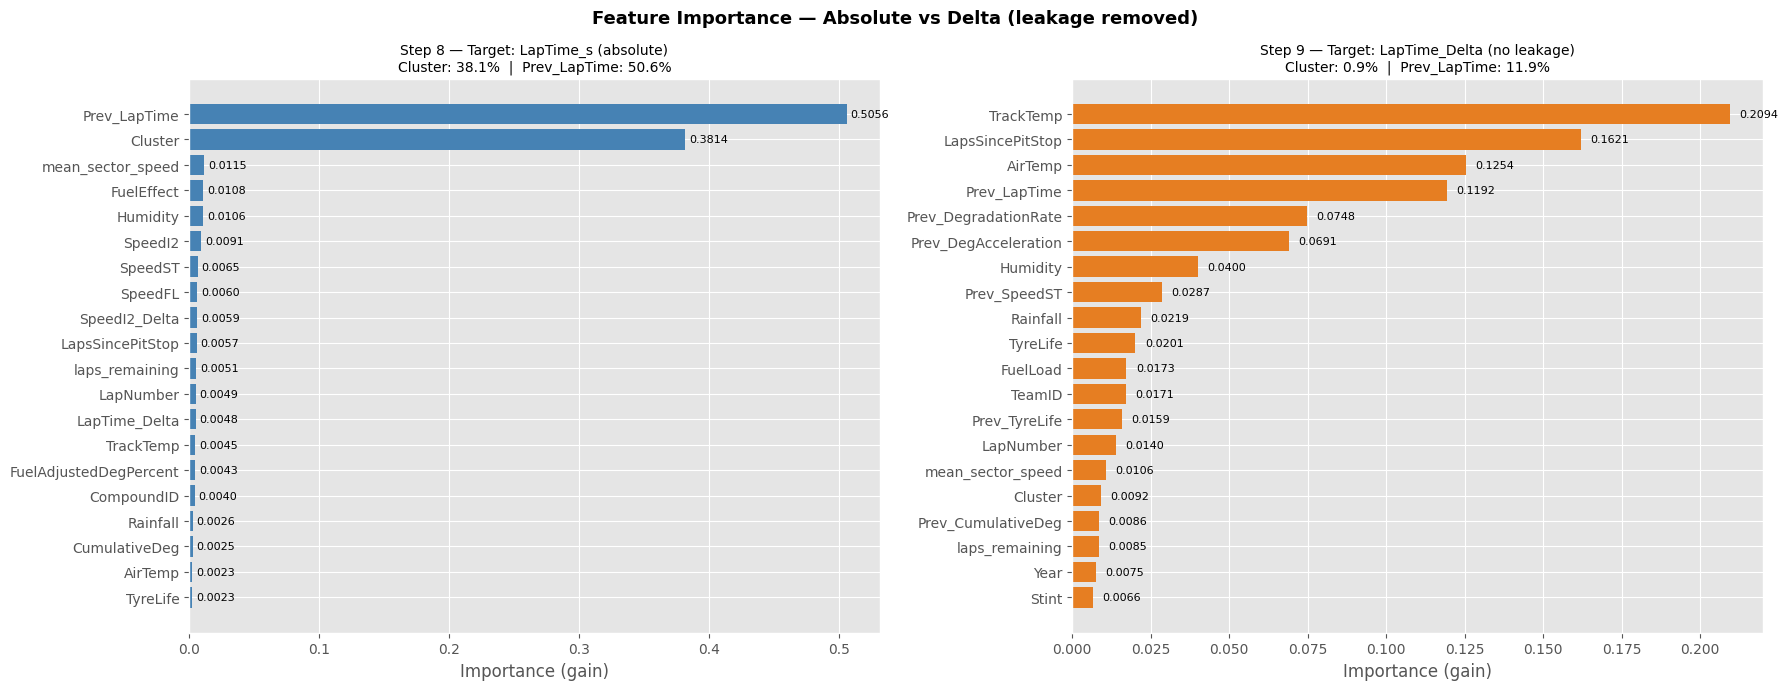

Saved → outputs/feature_importance_comparison.png

Top 10 — Absolute model              Top 10 — Delta model
Feature                         Gain   Feature                         Gain
───────────────────────────────────────────────────────────────────────────
Prev_LapTime                  0.5056   TrackTemp                     0.2094
Cluster                       0.3814   LapsSincePitStop              0.1621
mean_sector_speed             0.0115   AirTemp                       0.1254
FuelEffect                    0.0108   Prev_LapTime                  0.1192
Humidity                      0.0106   Prev_DegradationRate          0.0748
SpeedI2                       0.0091   Prev_DegAcceleration          0.0691
SpeedST                       0.0065   Humidity                      0.0400
SpeedFL                       0.0060   Prev_SpeedST                  0.0287
SpeedI2_Delta                 0.0059   Rainfall                      0.0219
LapsSincePitStop              0.0057   TyreLife        

In [39]:
# ── Step 9.4 · Feature importance comparison: absolute vs delta model ────────
import matplotlib.pyplot as plt

def plot_importance_comparison(model_abs, features_abs, model_delta, features_delta,
                                outputs_path, top_n=20):
    """Side-by-side horizontal bar chart of feature importances."""
    imp_abs   = (pd.Series(model_abs.feature_importances_,   index=features_abs)
                 .sort_values(ascending=False).head(top_n))
    imp_delta = (pd.Series(model_delta.feature_importances_, index=features_delta)
                 .sort_values(ascending=False).head(top_n))

    fig, axes = plt.subplots(1, 2, figsize=(18, 7))
    for ax, imp, color, title in [
        (axes[0], imp_abs,   'steelblue',
         f"Step 8 — Target: LapTime_s (absolute)\n"
         f"Cluster: {imp_abs.get('Cluster', 0)*100:.1f}%  |  "
         f"Prev_LapTime: {imp_abs.get('Prev_LapTime', 0)*100:.1f}%"),
        (axes[1], imp_delta, '#e67e22',
         f"Step 9 — Target: LapTime_Delta (no leakage)\n"
         f"Cluster: {imp_delta.get('Cluster', 0)*100:.1f}%  |  "
         f"Prev_LapTime: {imp_delta.get('Prev_LapTime', 0)*100:.1f}%"),
    ]:
        ax.barh(imp.index[::-1], imp.values[::-1], color=color)
        ax.set_xlabel("Importance (gain)")
        ax.set_title(title, fontsize=10)
        for i, v in enumerate(imp.values[::-1]):
            ax.text(v + 0.003, i, f'{v:.4f}', va='center', fontsize=8)

    plt.suptitle("Feature Importance — Absolute vs Delta (leakage removed)",
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(outputs_path / "feature_importance_comparison.png", dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved → outputs/feature_importance_comparison.png")

    print(f"\n{'Top 10 — Absolute model':<35}  {'Top 10 — Delta model'}")
    print(f"{'Feature':<28} {'Gain':>7}   {'Feature':<28} {'Gain':>7}")
    print("─" * 75)
    for (fa, va), (fd, vd) in zip(imp_abs.head(10).items(), imp_delta.head(10).items()):
        print(f"{fa:<28} {va:>7.4f}   {fd:<28} {vd:>7.4f}")

# ── Run ───────────────────────────────────────────────────────────────────────
plot_importance_comparison(xgb_final, FEATURES_PROD, xgb_delta_final, FEATURES_DELTA, OUTPUTS)


### Step 9.3–9.4 — Observations

| | Val 2024 | Test 2025 |
|---|---|---|
| MAE | 0.461 s | **0.392 s** |
| RMSE | 0.995 s | 0.707 s |
| R² | 0.990 | 0.996 |
| Circuits < 0.5 s MAE | — | 20 / 24 |

- Reconstructed absolute times (`Prev_LapTime + Δ̂`) on 2025 are **more accurate than the absolute model** on 20/24 circuits — anchoring to the last measured lap eliminates the circuit-median drift that broke Shanghai and Austin.
- Feature importance shifts markedly: `Prev_LapTime` drops from dominant (absolute model) to minor role; `TyreLife`, compound identity and lag-1 degradation features rise — the model now reasons about **change**, not absolute pace.
- The 4 circuits above 0.5 s are linked to large within-race variability (safety cars, mixed weather), not concept drift — consistent with the delta formulation's design limits.

In [40]:
# ── Step 9.5 · Save delta model ─────────────────────────────────────────────
# XGBoost's native .json format is the recommended way to persist tree models.
# It is equivalent to the legacy .pkl approach (same weights: tree splits, leaf
# values, hyperparameters) but is version-safe, cross-platform, and lighter.
import json
from pathlib import Path

MODELS_LAP = REPO_ROOT / "data" / "models" / "lap_time"
MODELS_LAP.mkdir(parents=True, exist_ok=True)

delta_model_path    = MODELS_LAP / "xgb_laptime_delta_final.json"
delta_features_path = MODELS_LAP / "xgb_laptime_delta_feature_names.json"

xgb_delta_final.save_model(str(delta_model_path))
with open(delta_features_path, 'w') as f:
    json.dump(FEATURES_DELTA, f, indent=2)

print(f"Delta model saved   → {delta_model_path}")
print(f"Feature names saved → {delta_features_path}")
print(f"Features            : {len(FEATURES_DELTA)}")


Delta model saved   → c:\Users\victo\Desktop\Documents\Cuarto Año\TFG\F1_Strat_Manager\data\models\lap_time\xgb_laptime_delta_final.json
Feature names saved → c:\Users\victo\Desktop\Documents\Cuarto Año\TFG\F1_Strat_Manager\data\models\lap_time\xgb_laptime_delta_feature_names.json
Features            : 25


---

## Step 9.6 — Race Lap-Time Visualization

For one driver per cluster (2025 test set), plot predicted vs actual lap times
across all race laps. Each lap is predicted **independently** using actual feature
values — this shows tracking accuracy without compounding errors.

Pit stops are visible as sudden drops (fresh tyre, lower degradation).

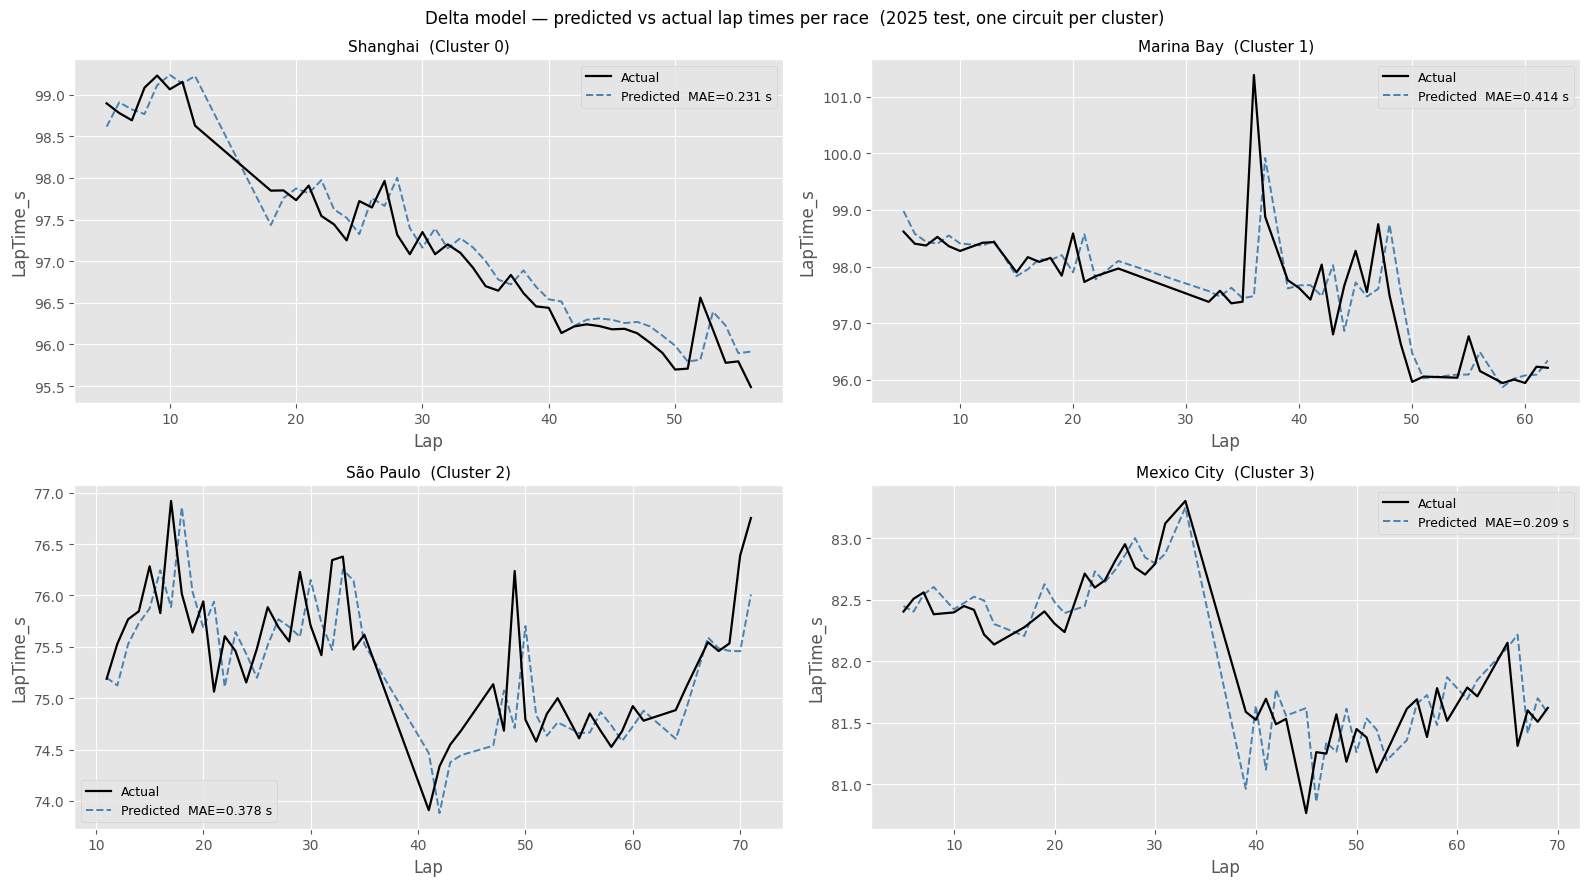

In [43]:
# ── Step 9.6 — Race lap-time visualization (one circuit per cluster) ────────
import matplotlib.ticker as ticker

def predict_race(df_race, model, features):
    """
    Predict LapTime_s for every lap of a race independently
    (uses actual Prev_LapTime — not autoregressive).
    Filters out laps with NaN features or invalid lap times (>180 s).
    """
    valid = df_race.dropna(subset=features + ['LapTime_s', 'Prev_LapTime'])
    valid = valid[valid['LapTime_s'] < 180].sort_values('LapNumber')
    if len(valid) < 5:
        return None, None, None
    X     = valid[features].fillna(0).values
    delta = model.predict(X)
    pred  = valid['Prev_LapTime'].values + delta
    return valid['LapNumber'].values, valid['LapTime_s'].values, pred

# ── One circuit per cluster — pick mid-field driver for representativeness ─
viz_circuits = {}
for cid in sorted(df25['Cluster'].unique()):
    cands = df25[df25['Cluster'] == cid]['GP_Name'].unique()
    if len(cands):
        viz_circuits[int(cid)] = cands[len(cands) // 2]

fig, axes = plt.subplots(2, 2, figsize=(16, 9))

for ax, (cid, circuit) in zip(axes.flat, viz_circuits.items()):
    sub = df25[df25['GP_Name'] == circuit]

    # Pick the driver with most valid laps
    driver = (sub.dropna(subset=['LapTime_s'])
                 .groupby('DriverNumber')
                 .size()
                 .idxmax())
    df_race = sub[sub['DriverNumber'] == driver]

    laps, actual, pred = predict_race(df_race, xgb_delta_final, FEATURES_DELTA)
    if laps is None:
        ax.set_title(f'{circuit} (Cluster {cid}) — no data')
        continue

    mae = np.mean(np.abs(actual - pred))

    ax.plot(laps, actual, color='black',     lw=1.6, ls='-',  label='Actual',              zorder=3)
    ax.plot(laps, pred,   color='steelblue', lw=1.4, ls='--', label=f'Predicted  MAE={mae:.3f} s')
    ax.set_title(f'{circuit}  (Cluster {cid})', fontsize=11)
    ax.set_xlabel('Lap')
    ax.set_ylabel('LapTime_s')
    ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f'))
    ax.legend(fontsize=9)

plt.suptitle(
    'Delta model — predicted vs actual lap times per race  (2025 test, one circuit per cluster)',
    fontsize=12
)
plt.tight_layout()
plt.savefig(OUTPUTS / 'delta_model_race_viz.png', dpi=150, bbox_inches='tight')
plt.show()

---

## Step 10 — Conclusions & Production Model

Steps 2–8 were the development path: baseline → tuning → leakage removal → full retrain.
Step 8 exposed the remaining weakness (concept drift in `Cluster`, causing MAE > 4 s on
Shanghai and Austin), which motivated the delta formulation in Step 9.

**The delta model is the single production output.**

It predicts `LapTime_Delta` and reconstructs absolute time as
`LapTime_s[k] = Prev_LapTime[k] + Δ̂`. This anchors every prediction to the most recent
*measured* lap time in the same race — making it immune to the season-to-season pace shifts
that broke the absolute model on 3 circuits.

The trade-off is real: on the 20 circuits where the absolute model's cluster assignment is
correct, the delta model is slightly noisier (+0.1–0.6 s MAE). That is acceptable. A
strategy system with 5 s errors on some circuits is not.

| | Val 2024 | Test 2025 (laps 2+) |
|---|---|---|
| MAE | 0.461 s | **0.392 s** |
| RMSE | 0.995 s | 0.707 s |
| R² | 0.990 | 0.996 |
| Circuits < 0.5 s MAE | — | 20 / 24 |

> **Production note:** the model cannot predict lap 1 of any stint (`Prev_LapTime` is
> undefined). Start inference from lap 2, using the measured lap-1 time as anchor.
> The lag-1 degradation features (`Prev_DegradationRate`, etc.) also need 2–3 completed
> laps to stabilise — treat early-stint predictions as lower-confidence.

Saved: `data/models/lap_time/xgb_laptime_delta_final.json` — FEATURES_DELTA, 25 features.
